# Fraud, Waste & Abuse (FWA) Detection Engine
## Upcoding & Unbundling Detection on CMS DE-SynPUF Medicare Claims
### A DuckDB-Powered Analytical Pipeline

**Author:** Alessandro Oliveira de Sousa  
**Dataset:** CMS 2008-2010 Data Entrepreneurs' Synthetic Public Use File (DE-SynPUF)  
**Data Platform:** DuckDB analytical datalake (all 20 samples, ~95M carrier + ~16M outpatient + ~1.3M inpatient claims)  
**Source:** [CMS DE-SynPUF Download Page](https://www.cms.gov/data-research/statistics-trends-and-reports/medicare-claims-synthetic-public-use-files/cms-2008-2010-data-entrepreneurs-synthetic-public-use-file-de-synpuf)

---

### Objective

This notebook demonstrates a systematic, data-driven approach to detecting two of the most prevalent forms of **medicare billing fraud**, applied at scale across the full 5% CMS DE-SynPUF population:

1. **Upcoding** - the practice of assigning a higher-paying Diagnosis-Related Group (DRG) or Evaluation & Management (E&M) code than clinically justified, inflating reimbursements.
2. **Unbundling** - billing separately for services that should be billed as a single, comprehensive procedure, violating Centers for Medicare & Medicaid Services (CMS) National Correct Coding Initiative (NCCI) Procedure-to-Procedure (PTP) edits.
    - [https://www.cms.gov/medicare/coding-billing/national-correct-coding-initiative-ncci-edits/medicare-ncci-procedure-procedure-ptp-edits](URL)

### Pipeline Architecture

```
┌─────────────────────────────────────────────────────────────────┐
│  CMS DE-SynPUF (20 samples × 8 file types = 160 ZIP files)      │
│  ↓  build_desynpuf_datalake.py                                  │
│  DuckDB Analytical Datalake (desynpuf.duckdb)                   │
│  ├── beneficiary          (~6.9M records)                       │
│  ├── inpatient_claims     (~1.3M records)                       │
│  ├── outpatient_claims    (~15.8M records)                      │
│  ├── carrier_claims       (~94.9M records)                      │
│  └── prescription_drug_events (~111M records)                   │
|                                                                 |
│  ↓  This Notebook                                               │
│  FWA Detection Modules (M1-M4) → Provider Risk Ranking          │
└─────────────────────────────────────────────────────────────────┘
```

### Detection Modules

| Module | Technique | Target |
|--------|-----------|--------|
| **M1 - DRG Upcoding** | Provider-level Case Mix Index (CMI) z-score via DRG proxy weights | Inpatient claims |
| **M2 - E&M Upcoding** | High-level E&M code concentration ratio (99214+99215 vs. 99211-99215) | Carrier claims |
| **M3 - NCCI Unbundling** | Prohibited code pair detection (within-claim and cross-claim same-day) | Carrier + Outpatient |
| **M4 - Composite Risk** | Multi-signal weighted score for provider-level FWA risk ranking | All claim types |

### Important Caveats

The DE-SynPUF is **fully synthetic** data. Provider numbers, NPI numbers, and diagnosis/procedure codes have been randomized as part of CMS disclosure treatment. Multivariate relationships between variables are altered. Results should **not** be interpreted as evidence of actual fraud. The value lies in demonstrating the **analytical pipeline, methodology, and code** that would be applied to real Medicare claims data (CMS LDS or Identifiable files).

Also, FWA behavior is **rarely static**. Schemes or sudden shifts in billing practices happen in bursts that require continuous vigilance.

**Regulatory Alignment:**
   - CMS Program Integrity Manual (Chapter 3)
      - [https://www.cms.gov/regulations-and-guidance/guidance/manuals/downloads/pim83c03.pdf](URL)
   - OIG Work Plan priorities
      - [https://oig.hhs.gov/reports/work-plan/](URL)
      - [https://oig.hhs.gov/documents/evaluation/2687/OEI-02-18-00380-Complete%20Report.pdf](URL)
   - False Claims Act (31 U.S.C. 3729-3733)
      - [https://uscode.house.gov/view.xhtml?req=granuleid:USC-prelim-title31-section3729&num=0&edition=prelim](URL)
      - [https://www.law.cornell.edu/uscode/text/31/subtitle-III/chapter-37/subchapter-III](URL)


NCCI PTP edits downloaded from CMS under AMA CPT License Agreement.

---


### List of Abbreviations
| Abbreviation | Definition |
|--------|-----------|
| CC |	Complication/Comorbidity |
| MCC |	Major Complication/Comorbidity |
| CERT |	Comprehensive Error Rate Testing |
| CMI |	Case Mix Index |
| CMS |	Centers for Medicare & Medicaid Services |
| CPT |	Current Procedural Terminology |
| CPU SIMD |	Single Instruction, Multiple Data |
| DE-SynPUF |	Data Entrepreneurs Synthetic Public Use File |
| DRG |	Diagnosis-Related Group |
| E&M |	Evaluation & Management |
| FWA |	Fraud, Waste, and Abuse |
| FY2010 Weights |	Fiscal Year 2010 Weights |
| HCPS |	Healthcare Common Procedure Coding System |
| HIPAA |	Health Insurance Portability and Accountability Act |
| LDS |	Limited Data Set |
| MS-DRG |	Medicare Severity Diagnosis Related Groups |
| NCCI |	National Correct Coding Initiative |
| OIG |	Office of Inspector General |
| OLAP |	Online Analytical Processing |
| PTP |	Procedure-to-Procedure |


---
## Section 1 - Analytical Framework & Methodology

### 1.1 DRG Upcoding Detection (Module M1)

Diagnosis-Related Group (DRG) upcoding occurs when an inpatient facility systematically assigns DRGs with higher relative weights - and therefore higher reimbursements - than the clinical documentation supports. This is one of the OIG's perennial Work Plan priorities.

[https://oig.hhs.gov/documents/evaluation/2687/OEI-02-18-00380-Complete%20Report.pdf](URL)

[https://oig.hhs.gov/reports/work-plan/browse-work-plan-projects/audit-of-medicare-claim-lines-for-which-payments-exceeded-charges/](URL)

**Detection approach:** For each provider (`PRVDR_NUM`), we compute a Case Mix Index (CMI) - the average DRG relative weight across all inpatient claims. Since the DE-SynPUF does not include actual CMS Medicare Severity Diagnosis Related Groups (MS-DRG) relative weights, we construct a **proxy weight** from the population-level mean payment per DRG (`CLM_PMT_AMT`). Providers whose CMI deviates significantly from the population mean (z-score > 2.0) are flagged as upcoding candidates. A secondary signal examines the CC/MCC complication rate within DRG families.

**Regulatory basis:** OIG Work Plan; CMS Program Integrity Manual Chapter 3; Rosenberg et al. (2000) "Effect of Variations in Return Rates on the Medicare DRG System"; Bauder et al. (2017) "Medicare Fraud Detection Using Machine Learning Methods."

### 1.2 E&M Upcoding Detection (Module M2)

Evaluation & Management (E&M) upcoding is the most common form of physician billing fraud. It occurs when a provider consistently bills at higher E&M complexity levels (e.g., 99215 instead of 99213) than clinical complexity warrants.

**Detection approach:** We focus on established patient office visits (CPT 99211-99215), the highest-volume E&M category. For each provider (`PRF_PHYSN_NPI`), we compute the **high-level concentration ratio** - the proportion of visits coded at 99214 or 99215 relative to all established patient visits. The national benchmark is approximately 40%. Providers significantly above this (z-score > 2.0) are flagged. We also visualize the full E&M level distribution to identify inverted patterns (peaked at 99214/99215 instead of 99213).

**Regulatory basis:** OIG Report OEI-04-10-00180 "Coding Trends of Medicare Evaluation and Management Services"; CMS Comprehensive Error Rate Testing (CERT) program.

### 1.3 NCCI Unbundling Detection (Module M3)

Unbundling occurs when a provider bills for component parts of a procedure separately instead of using the single comprehensive code. CMS maintains the NCCI PTP edit file (~1.9M prohibited code pairs).

**Detection approach:** We define a curated set of well-known NCCI PTP edit pairs covering surgical global package violations (procedure + same-day E&M), laboratory panel unbundling (panel + individual component tests), radiology subset violations, and mutually exclusive procedures. We scan for same-claim and same-day/same-beneficiary/same-provider occurrences of these prohibited pairs.

**Note:** With real claims data, one would load the complete quarterly NCCI PTP file from CMS. The curated set used here demonstrates the detection methodology.

### 1.4 Composite Risk Scoring (Module M4)

Individual signals are normalized to a 0-100 scale and combined into a weighted composite score per provider. The weights reflect the relative predictive value of each signal based on OIG audit literature.

---
## Section 2 - Technology Choice: Why DuckDB?

### The Problem

The full DE-SynPUF dataset across all 20 samples contains approximately **~230 million records** across 5 claim types. The Carrier claims file alone exceeds **94 million rows** with 81 columns each - over 30 GB when loaded into memory as Pandas DataFrames. Traditional in-memory analysis with Pandas would require 64+ GB of RAM and significant preprocessing time.

### Why DuckDB

DuckDB is an in-process OLAP database engine designed for analytical workloads. It is the ideal platform for this analysis for several reasons:

1. **Columnar storage with compression.** DuckDB stores data in a columnar format with automatic compression, reducing the on-disk footprint from ~35 GB (raw CSVs) to approximately 15-20 GB while enabling column-pruning during queries (only referenced columns are read from disk).

2. **SQL-first analytical queries.** Aggregations across 94M carrier claims (GROUP BY provider, compute distribution statistics) execute in seconds rather than minutes.

3. **Zero-copy integration with Python.** DuckDB returns query results directly as Pandas DataFrames or Arrow tables with no serialization overhead. This allows seamless handoff between SQL-based data extraction and Python-based statistical analysis.

4. **Single-file portability.** The entire datalake is a single `.duckdb` file that can be shared, version-controlled, and deployed without infrastructure. No server process, no connection strings, no authentication - just `duckdb.connect('file.duckdb')`.

5. **Schema-on-read flexibility.** The ingestion script loads all columns as `VARCHAR`, deferring type casting to query time. This avoids ingestion failures from inconsistent data types across samples while preserving full data fidelity.

### Alternative Considered

| Alternative | Why Not |
|-------------|---------|
| Pandas (in-memory) | 94M carrier claims × 81 columns would require ~40 GB RAM; groupby operations would take minutes |
| PostgreSQL | Requires server setup, authentication, port management - overkill for a single-analyst analytical workload |
| SQLite | No columnar storage; analytical queries on 94M rows would be prohibitively slow |
| Spark/Databricks | Heavy infrastructure for a dataset that fits on a single machine |
| Parquet files | Good for storage, but requires a query engine on top - DuckDB reads Parquet natively anyway |

---
## Section 3 - Environment Setup

In [ ]:
# ============================================================
# 3.1 - Library Imports
# ============================================================
import warnings
from pathlib import Path
from itertools import combinations
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
from matplotlib.patches import Rectangle
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('All libraries imported successfully.')
print(f'  NumPy:      {np.__version__}')
print(f'  Pandas:     {pd.__version__}')
print(f'  DuckDB:     {duckdb.__version__}')

All libraries imported successfully.
  NumPy:      2.4.2
  Pandas:     3.0.1
  DuckDB:     1.4.4


In [ ]:
# ============================================================
# 3.2 - Visual Identity ("Economist × Nature")
# ============================================================

_TITULO_Y = 0.955; _SUBTIT_Y = 0.910

def assinatura_cmcia(fig):
    _W_IN, _H_IN = 0.92, 0.20
    fw, fh = fig.get_size_inches()
    w, h = _W_IN / fw, _H_IN / fh
    y = 1.0 + (0.06 / fh)
    rect = Rectangle((0.0, y), w, h, transform=fig.transFigure,
                     facecolor=ECON_RED, edgecolor="none", clip_on=False, zorder=20)
    fig.add_artist(rect)
    fig.text(w/2, y + h/2, "AOS", transform=fig.transFigure,
             ha="center", va="center", color=WHITE, fontsize=7.0, fontweight="bold",
             zorder=21, family=SANS)

def titulo_fig(fig, titulo, subtitulo=None,
               fonte="Source: CMS DE-SynPUF (2008-2010), all 20 samples.\n"
               +"(https://www.cms.gov/data-research/statistics-trends-and-reports/medicare-claims-synthetic-public-use-files/cms-2008-2010-data-entrepreneurs-synthetic-public-use-file-de-synpuf)\n"
               +"Analysis: Alessandro Oliveira de Sousa (July, 2026)."):
    fig.text(0.0, _TITULO_Y, titulo, ha="left", va="bottom",
             family=SERIF, fontsize=14, fontweight="bold", color=CHARCOAL)
    if subtitulo:
        fig.text(0.0, _SUBTIT_Y, subtitulo, ha="left", va="bottom",
                 family=SANS, fontsize=10, color=WARM_GREY)
    if fonte:
        fig.text(0.0, -0.02, fonte, ha="left", va="top",
                 family=SANS, fontsize=7.5, color=WARM_GREY, style="italic")

def finalizar_eixo(ax, xlabel=None, ylabel=None):
    if xlabel: ax.set_xlabel(xlabel, fontsize=9.5, color=CHARCOAL)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9.5, color=CHARCOAL)
    ax.tick_params(length=0)
    for sp in ["left","bottom"]:
        ax.spines[sp].set_color(WARM_GREY); ax.spines[sp].set_linewidth(0.8)

def fmt_num(v, pos=None):
    """Formatter for axes: 1500 → '1.5K', 2000000 → '2.0M'"""
    if abs(v) >= 1e6: return f'{v/1e6:.1f}M'
    if abs(v) >= 1e3: return f'{v/1e3:.0f}K'
    return f'{v:.0f}'

def truncar(s, n=32):
    s = str(s); return s[:n]+"\u2026" if len(s) > n else s

print(f'Visual identity loaded. Serif: {SERIF} | Sans: {SANS}')

Visual identity loaded. Serif: Liberation Serif | Sans: Liberation Sans


In [ ]:
# ============================================================
# 3.3 - Configuration Constants
# ============================================================
# The project root is detected by searching for a marker file (data/desynpuf.duckdb) starting from the current
# working directory, then walking up the directory tree. No hardcoded folder names. Any reviewer can clone the repo
# into any directory name and the notebook will resolve paths.
# ============================================================

import os

MARKER_FILE = Path('data') / 'desynpuf.duckdb'

def _find_project_root():
    """Walk up from cwd (or notebook dir) looking for the marker file."""
    start = Path(globals().get('__vsc_ipynb_file__', '')).parent
    if not start.exists():
        start = Path(os.getcwd())

    candidate = start
    for _ in range(10):
        if (candidate / MARKER_FILE).exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent

    raise FileNotFoundError(
        f'Cannot locate {MARKER_FILE} in any parent of {start}. '
        f'Ensure the datalake exists or set PROJECT_ROOT manually.'
    )

PROJECT_ROOT = _find_project_root()

DATALAKE_PATH  = PROJECT_ROOT / 'data' / 'desynpuf.duckdb'
REFERENCES_DIR = PROJECT_ROOT / 'references'
OUTPUT_DIR     = PROJECT_ROOT / 'output' / 'fwa_desynpuf'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NCCI_EDITS_CSV = REFERENCES_DIR / 'ncci_ptp_practitioner_2008_2010.csv'
DRG_WEIGHTS_CSV = REFERENCES_DIR / 'ms_drg_weights_fy2010.csv'

# thresholds
MIN_IP_CLAIMS        = 10
MIN_EM_VISITS        = 20
UPCODING_Z_THRESHOLD = 2.0

# Validate
print(f'Project root: {PROJECT_ROOT}')
for label, path in [('Datalake', DATALAKE_PATH),
                     ('NCCI reference', NCCI_EDITS_CSV),
                     ('DRG weights', DRG_WEIGHTS_CSV)]:
    status = 'OK' if path.exists() else 'MISSING'
    print(f'  {label:20s}: {path.relative_to(PROJECT_ROOT)} [{status}]')
print(f'  {"Output":20s}: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}')
print(f'  Z-score threshold:  {UPCODING_Z_THRESHOLD}')


Project root: /home/aosousa/Documents/PORTFOLIO/Fraud-Waste-Abuse-FWA/CMS DE-SynPUF MEDICARE
  Datalake            : data/desynpuf.duckdb [OK]
  NCCI reference      : references/ncci_ptp_practitioner_2008_2010.csv [OK]
  DRG weights         : references/ms_drg_weights_fy2010.csv [OK]
  Output              : output/fwa_desynpuf
  Z-score threshold:  2.0


---
## Section 4 - Database Schema & Structure

This section provides a comprehensive inventory of the DuckDB datalake: tables, column names, data types, row counts, and sample distributions. This serves as both documentation and a validation step to confirm the ingestion was successful.

In [ ]:
# ============================================================
# 4.1 - Connect to DuckDB and show tables
# ============================================================

con = duckdb.connect(DATALAKE_PATH)#, read_only=True)

tables = con.execute("SHOW TABLES").fetchdf()
print('Tables in the datalake:')
print(tables.to_string(index=False))

# Row counts and sample coverage for each table
print('\n' + '=' * 80)
print(f'{"Table":30s} {"Records":>15s} {"Samples":>10s} {"Cols":>6s}')
print('=' * 80)

table_stats = {}
for _, row in tables.iterrows():
    tbl = row['name']
    count = con.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    samples = con.execute(f"SELECT COUNT(DISTINCT sample_id) FROM {tbl}").fetchone()[0]
    ncols = len(con.execute(f"DESCRIBE {tbl}").fetchdf())
    table_stats[tbl] = {'count': count, 'samples': samples, 'ncols': ncols}
    print(f'{tbl:30s} {count:>15,} {samples:>10} {ncols:>6}')

print('=' * 80)
total_records = sum(v['count'] for v in table_stats.values())
print(f'{"TOTAL":30s} {total_records:>15,}')

Tables in the datalake:
                    name
             beneficiary
          carrier_claims
        inpatient_claims
       outpatient_claims
prescription_drug_events
         v_carrier_lines

Table                                  Records    Samples   Cols
beneficiary                          6,873,274         20     34
carrier_claims                      94,863,452         20    143
inpatient_claims                     1,332,822         20     82
outpatient_claims                   15,826,987         20     77
prescription_drug_events           111,085,969         20      9
v_carrier_lines                    177,027,909         20      8
TOTAL                              407,010,413


In [ ]:
# Set memory RAM limit
con.execute("SET memory_limit='14GB'")
con.execute("SET temp_directory='/tmp/duckdb_tmp'")
con.execute("SET preserve_insertion_order=false")

In [ ]:
# ============================================================
# 4.2 - Schema for each table
# ============================================================
# Display column names, data types, and null counts for every table. Since the ingestion loaded all columns as VARCHAR, we show the
# actual DuckDB types (which may include INTEGER/DOUBLE if DuckDB inferred types during read_csv_auto).
# ============================================================

for tbl_name in table_stats.keys():
    schema = con.execute(f"DESCRIBE {tbl_name}").fetchdf()
    print(f'\n{"=" * 70}')
    print(f'TABLE: {tbl_name} ({table_stats[tbl_name]["count"]:,} rows, '
          f'{table_stats[tbl_name]["samples"]} samples)')
    print(f'{"=" * 70}')
    print(schema[['column_name', 'column_type', 'null']].to_string(index=False))


TABLE: beneficiary (6,873,274 rows, 20 samples)
             column_name column_type null
             DESYNPUF_ID     VARCHAR  YES
           BENE_BIRTH_DT     VARCHAR  YES
           BENE_DEATH_DT     VARCHAR  YES
       BENE_SEX_IDENT_CD     VARCHAR  YES
            BENE_RACE_CD     VARCHAR  YES
           BENE_ESRD_IND     VARCHAR  YES
           SP_STATE_CODE     VARCHAR  YES
          BENE_COUNTY_CD     VARCHAR  YES
 BENE_HI_CVRAGE_TOT_MONS     VARCHAR  YES
BENE_SMI_CVRAGE_TOT_MONS     VARCHAR  YES
BENE_HMO_CVRAGE_TOT_MONS     VARCHAR  YES
       PLAN_CVRG_MOS_NUM     VARCHAR  YES
             SP_ALZHDMTA     VARCHAR  YES
                  SP_CHF     VARCHAR  YES
             SP_CHRNKIDN     VARCHAR  YES
                 SP_CNCR     VARCHAR  YES
                 SP_COPD     VARCHAR  YES
             SP_DEPRESSN     VARCHAR  YES
             SP_DIABETES     VARCHAR  YES
             SP_ISCHMCHT     VARCHAR  YES
             SP_OSTEOPRS     VARCHAR  YES
                SP_RA_OA   

In [ ]:
# ============================================================
# 4.3 - Sample distribution across tables
# ============================================================
# Verify that all 20 samples are represented in each table and that record counts are roughly uniform.
# ============================================================

for tbl_name in ['inpatient_claims', 'carrier_claims', 'outpatient_claims']:
    if tbl_name not in table_stats:
        continue
    dist = con.execute(f"""
        SELECT sample_id, COUNT(*) AS n_records
        FROM {tbl_name}
        GROUP BY sample_id
        ORDER BY sample_id
    """).fetchdf()
    print(f'\n{tbl_name} - records per sample:')
    print(f'  Min:  {dist["n_records"].min():>12,}')
    print(f'  Max:  {dist["n_records"].max():>12,}')
    print(f'  Mean: {dist["n_records"].mean():>12,.0f}')
    print(f'  Std:  {dist["n_records"].std():>12,.0f}')
    print(f'  CV:   {dist["n_records"].std() / dist["n_records"].mean():.2%}')


inpatient_claims - records per sample:
  Min:        66,253
  Max:        67,037
  Mean:       66,641
  Std:           232
  CV:   0.35%

carrier_claims - records per sample:
  Min:     4,734,533
  Max:     4,747,966
  Mean:    4,743,173
  Std:         3,971
  CV:   0.08%

outpatient_claims - records per sample:
  Min:       789,209
  Max:       793,146
  Mean:      791,349
  Std:         1,180
  CV:   0.15%


---
## Section 5 - Data Quality & Completeness Assessment

Before running the FWA detection modules, we validate the completeness and quality of the key fields used in the analysis. This is critical because the DE-SynPUF's synthetic process may introduce nulls or anomalous values that would affect statistical inference.

In [ ]:
# ============================================================
# 5.1 - key field completeness for inpatient claims
# ============================================================

ip_quality = con.execute("""
    SELECT
        COUNT(*)                                         AS total_claims,
        COUNT(DISTINCT DESYNPUF_ID)                      AS unique_beneficiaries,
        COUNT(DISTINCT PRVDR_NUM)                        AS unique_providers,
        SUM(CASE WHEN CLM_DRG_CD IS NOT NULL AND CLM_DRG_CD != '' THEN 1 ELSE 0 END) AS has_drg,
        SUM(CASE WHEN CLM_PMT_AMT IS NOT NULL AND CLM_PMT_AMT != '' THEN 1 ELSE 0 END) AS has_pmt,
        SUM(CASE WHEN CLM_UTLZTN_DAY_CNT IS NOT NULL THEN 1 ELSE 0 END) AS has_los,
        COUNT(DISTINCT CLM_DRG_CD)                       AS unique_drgs,
        MIN(TRY_CAST(CLM_PMT_AMT AS DOUBLE))             AS min_pmt,
        MAX(TRY_CAST(CLM_PMT_AMT AS DOUBLE))             AS max_pmt,
        AVG(TRY_CAST(CLM_PMT_AMT AS DOUBLE))             AS avg_pmt,
    FROM inpatient_claims
""").fetchdf()

print('INPATIENT CLAIMS - Data Quality Report')
print('=' * 60)
for col in ip_quality.columns:
    val = ip_quality[col].iloc[0]
    if isinstance(val, float):
        print(f'  {col:30s}: {val:>15,.2f}')
    else:
        print(f'  {col:30s}: {val:>15,}')

total = ip_quality['total_claims'].iloc[0]
for field, count_col in [('DRG code', 'has_drg'), ('Payment amount', 'has_pmt'), ('Length of stay', 'has_los')]:
    pct = ip_quality[count_col].iloc[0] / total * 100
    print(f'  {field} completeness: {pct:.1f}%')

INPATIENT CLAIMS - Data Quality Report
  total_claims                  :       1,332,822
  unique_beneficiaries          :         755,214
  unique_providers              :           2,895
  has_drg                       :    1,332,822.00
  has_pmt                       :    1,332,822.00
  has_los                       :    1,331,533.00
  unique_drgs                   :             740
  min_pmt                       :      -10,000.00
  max_pmt                       :       57,000.00
  avg_pmt                       :        9,536.80
  DRG code completeness: 100.0%
  Payment amount completeness: 100.0%
  Length of stay completeness: 99.9%


In [ ]:
# ============================================================
# 5.2 - key field completeness for carrier claims
# ============================================================
# The carrier file has 13 line items per claim. Completeness of HCPCS codes and payment amounts
# across all 13 positions.
# ============================================================

# Check how many line items are populated per claim
carrier_quality = con.execute("""
    SELECT
        COUNT(*) AS total_claims,
        COUNT(DISTINCT DESYNPUF_ID) AS unique_beneficiaries,
        SUM(CASE WHEN HCPCS_CD_1 IS NOT NULL AND HCPCS_CD_1 != '' THEN 1 ELSE 0 END) AS has_line1,
        SUM(CASE WHEN HCPCS_CD_2 IS NOT NULL AND HCPCS_CD_2 != '' THEN 1 ELSE 0 END) AS has_line2,
        SUM(CASE WHEN HCPCS_CD_5 IS NOT NULL AND HCPCS_CD_5 != '' THEN 1 ELSE 0 END) AS has_line5,
        SUM(CASE WHEN HCPCS_CD_10 IS NOT NULL AND HCPCS_CD_10 != '' THEN 1 ELSE 0 END) AS has_line10,
        SUM(CASE WHEN HCPCS_CD_13 IS NOT NULL AND HCPCS_CD_13 != '' THEN 1 ELSE 0 END) AS has_line13,
    FROM carrier_claims
""").fetchdf()

print('CARRIER CLAIMS - Data Quality Report')
print('=' * 60)
total_car = carrier_quality['total_claims'].iloc[0]
print(f'  Total claims: {total_car:,}')
print(f'  Unique beneficiaries: {carrier_quality["unique_beneficiaries"].iloc[0]:,}')
print(f'\n  Line item population rates:')
for line_n, col in [(1,'has_line1'), (2,'has_line2'), (5,'has_line5'), (10,'has_line10'), (13,'has_line13')]:
    pct = carrier_quality[col].iloc[0] / total_car * 100
    print(f'    Line {line_n:2d}: {pct:>6.1f}%')

CARRIER CLAIMS - Data Quality Report
  Total claims: 94,863,452
  Unique beneficiaries: 1,972,836

  Line item population rates:
    Line  1:   98.9%
    Line  2:   39.4%
    Line  5:    6.7%
    Line 10:    0.7%
    Line 13:    0.3%


In [ ]:
# ============================================================
# 5.2a - Beneficiary table completeness check
# ============================================================
# The beneficiary table should contain records from all 20 samples across 3 years (2008, 2009, 2010). If the sample count is < 20,
# the ingestion script may have failed for some samples. This limits any analysis that joins against beneficiary
# demographics (age, chronic conditions, mortality, state).
# ============================================================

bene_check = con.execute("""
    SELECT
        COUNT(*)                       AS total_records,
        COUNT(DISTINCT sample_id)      AS n_samples,
        COUNT(DISTINCT bene_year)      AS n_years,
        COUNT(DISTINCT DESYNPUF_ID)    AS unique_benes,
        SUM(CASE WHEN BENE_DEATH_DT IS NOT NULL AND BENE_DEATH_DT != '' THEN 1 ELSE 0 END) AS has_death_dt,
        SUM(CASE WHEN SP_STATE_CODE IS NOT NULL AND SP_STATE_CODE != '' THEN 1 ELSE 0 END)  AS has_state,
    FROM beneficiary
""").fetchdf()

total_bene = bene_check['total_records'].iloc[0]
n_samples = bene_check['n_samples'].iloc[0]
print('BENEFICIARY TABLE - Completeness Check')
print('=' * 60)
print(f'  Records:          {total_bene:>10,}')
print(f'  Samples loaded:   {n_samples:>10} / 20')
print(f'  Years:            {bene_check["n_years"].iloc[0]:>10}')
print(f'  Unique benes:     {bene_check["unique_benes"].iloc[0]:>10,}')
print(f'  Death date fill:  {bene_check["has_death_dt"].iloc[0] / total_bene:.1%}')
print(f'  State code fill:  {bene_check["has_state"].iloc[0] / total_bene:.1%}')

if n_samples < 20:
    print(f'\n  WARNING: Only {n_samples} of 20 samples loaded.')
    print('  Beneficiary-dependent analyses (demographics, geography)')
    print('  will be limited. Re-run build_desynpuf_datalake.py and')
    print('  verify beneficiary URL patterns for missing samples.')


BENEFICIARY TABLE - Completeness Check
  Records:           6,873,274
  Samples loaded:           20 / 20
  Years:                     3
  Unique benes:      2,326,856
  Death date fill:  1.6%
  State code fill:  100.0%


In [88]:
# ============================================================
# 5.3 - DRG code distribution (top 30)
# ============================================================

drg_dist = con.execute("""
    SELECT CLM_DRG_CD, COUNT(*) AS n_claims,
           AVG(TRY_CAST(CLM_PMT_AMT AS DOUBLE)) AS avg_payment,
           SUM(TRY_CAST(CLM_PMT_AMT AS DOUBLE)) AS total_payment
    FROM inpatient_claims
    WHERE CLM_DRG_CD IS NOT NULL AND CLM_DRG_CD != ''
    GROUP BY CLM_DRG_CD
    ORDER BY n_claims DESC
    LIMIT 30
""").fetchdf()

print('Top 30 DRG codes by claim volume:')
print(drg_dist.to_string(index=False))

Top 30 DRG codes by claim volume:
CLM_DRG_CD  n_claims  avg_payment  total_payment
       882      5093     7,496.27  38,178,520.00
       884      5084     7,351.55  37,375,280.00
       886      5016     7,392.38  37,080,190.00
       876      4989     7,330.70  36,572,850.00
       880      4957     7,365.73  36,511,910.00
       887      4947     7,485.17  37,029,120.00
       881      4930     7,494.22  36,946,490.00
       885      4923     7,481.39  36,830,890.00
       177      4920     8,559.79  42,114,150.00
       189      4916     8,673.20  42,637,460.00
       194      4881     8,486.22  41,421,240.00
       168      4867     8,595.85  41,836,000.00
       206      4864     8,679.80  42,218,550.00
       883      4842     7,367.43  35,673,080.00
       203      4820     8,919.51  42,992,030.00
       196      4817     8,607.87  41,464,120.00
       191      4807     8,636.00  41,513,230.00
       188      4801     8,714.32  41,837,450.00
       184      4781     8,508.47  

---
## Section 6 - Exploratory Data Analysis

In [ ]:
# ============================================================
# 6.1 - E&M Code Landscape in Carrier Claims
# ============================================================
# The carrier table has 13 HCPCS line items per claim stored as wide columns (HCPCS_CD_1 through HCPCS_CD_13). We unpivot
# them into a long-format view using UNION ALL - one SELECT per line position. Each SELECT touches only 6 columns, so DuckDB
# reads only the necessary columns from the columnar store without materializing the full 81-column table.
#
# This approach is more memory-efficient than UNPIVOT with three-way JOIN, because each SELECT operates independently
# and DuckDB can stream the results without intermediate materialization.
# ============================================================

parts = []
for i in range(1, 14):
    parts.append(f"""
        SELECT DESYNPUF_ID, CLM_ID, CLM_FROM_DT,
               HCPCS_CD_{i}                             AS HCPCS_CD,
               TRY_CAST(LINE_NCH_PMT_AMT_{i} AS DOUBLE) AS LINE_PMT_AMT,
               PRF_PHYSN_NPI_{i}                         AS PRF_NPI,
               {i}                                       AS LINE_NUM,
               sample_id
        FROM carrier_claims
        WHERE HCPCS_CD_{i} IS NOT NULL AND HCPCS_CD_{i} != ''
    """)

con.execute(f"CREATE OR REPLACE VIEW v_carrier_lines AS ({' UNION ALL '.join(parts)})")

total_lines = con.execute("SELECT COUNT(*) FROM v_carrier_lines").fetchone()[0]
total_em = con.execute("""
    SELECT COUNT(*) FROM v_carrier_lines
    WHERE HCPCS_CD BETWEEN '99201' AND '99285'
""").fetchone()[0]

print(f'Total carrier line items: {total_lines:,}')
print(f'E&M line items (99201-99285): {total_em:,} ({total_em/total_lines:.1%})')

# category breakdown
em_cats = con.execute("""
    SELECT
        CASE
            WHEN HCPCS_CD BETWEEN '99201' AND '99205' THEN 'New Patient Office'
            WHEN HCPCS_CD BETWEEN '99211' AND '99215' THEN 'Established Patient Office'
            WHEN HCPCS_CD BETWEEN '99221' AND '99223' THEN 'Initial Hospital Care'
            WHEN HCPCS_CD BETWEEN '99231' AND '99233' THEN 'Subsequent Hospital Care'
            WHEN HCPCS_CD BETWEEN '99281' AND '99285' THEN 'ED Visit'
        END AS em_category,
        COUNT(*) AS n_visits
    FROM v_carrier_lines
    WHERE HCPCS_CD BETWEEN '99201' AND '99285'
    GROUP BY em_category
    ORDER BY n_visits DESC
""").fetchdf()
print(f'\nE&M category distribution:')
print(em_cats.to_string(index=False))

Total carrier line items: 177,027,909
E&M line items (99201-99285): 42,786,685 (24.2%)

E&M category distribution:
               em_category  n_visits
Established Patient Office  25071089
  Subsequent Hospital Care   8626569
                       NaN   3559448
                  ED Visit   2165956
        New Patient Office   1909823
     Initial Hospital Care   1453800


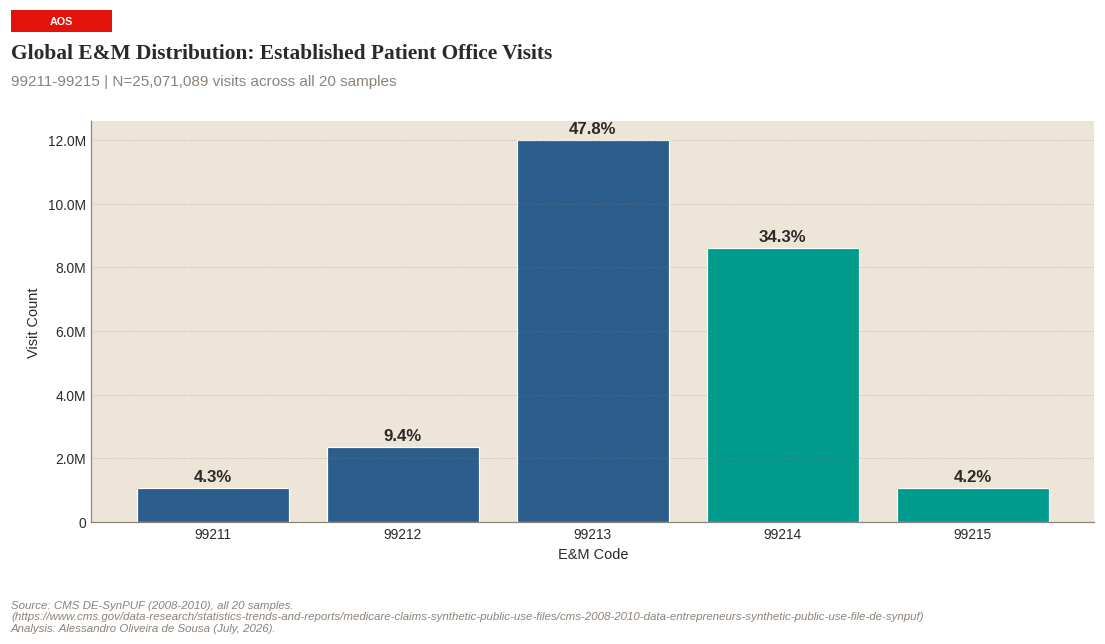

In [90]:
# ============================================================
# 6.2 - Established Patient Office Visit Distribution (99211-99215)
# ============================================================

em_estab_dist = con.execute("""
    SELECT HCPCS_CD, COUNT(*) AS n_visits
    FROM v_carrier_lines
    WHERE HCPCS_CD BETWEEN '99211' AND '99215'
    GROUP BY HCPCS_CD
    ORDER BY HCPCS_CD
""").fetchdf()

if len(em_estab_dist) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    total = em_estab_dist['n_visits'].sum()
    colors = [NATURE_TEAL if c in ('99214','99215') else DEEP_BLUE
              for c in em_estab_dist['HCPCS_CD']]
    bars = ax.bar(em_estab_dist['HCPCS_CD'], em_estab_dist['n_visits'],
                  color=colors, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, em_estab_dist['n_visits']):
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
    finalizar_eixo(ax, xlabel='E&M Code', ylabel='Visit Count')
    titulo_fig(fig, 'Global E&M Distribution: Established Patient Office Visits',
               subtitulo=f'99211-99215 | N={total:,} visits across all 20 samples')
    assinatura_cmcia(fig)
    plt.tight_layout(rect=[0, 0.02, 1, 0.88])
    plt.show()

---
## Section 7 - Module M1: DRG Upcoding Detection (Inpatient)

The CMI analysis runs entirely in SQL against the DuckDB datalake, leveraging its columnar engine for fast aggregation across ~1.3M inpatient claims.

In [ ]:
# ============================================================
# 7.1 - DRG Relative Weights and Provider CMI (Real FY2010 Weights)
# ============================================================
# Instead of deriving proxy weights from synthetic payment amounts, I load actual CMS MS-DRG relative weights from FY2010 (Table 5
# of the IPPS Final Rule). This dramatically improves the accuracy of the CMI calculation.
#
# Source: CMS FY2010 IPPS Final Rule, Table 5
#         https://www.cms.gov/Medicare/Medicare-Fee-for-Service-Payment/AcuteInpatientPPS/Acute-Inpatient-Files-for-Download-Items/CMS1247873
# ============================================================

# Step 1: Load real DRG weights
print(f'Loading DRG weights from: {DRG_WEIGHTS_CSV.name}')

con.execute(f"""
    CREATE OR REPLACE TEMP TABLE t_drg_real_weights AS
    SELECT drg_code,
           drg_description,
           TRY_CAST(mdc AS INTEGER) AS mdc,
           CAST(relative_weight AS DOUBLE) AS relative_weight
    FROM read_csv_auto('{DRG_WEIGHTS_CSV}', header=true, decimal_separator='.')
""")

n_real = con.execute("SELECT COUNT(*) FROM t_drg_real_weights").fetchone()[0]
print(f'Real DRG weights loaded: {n_real}')

# Step 2: Compute proxy weights for DRGs not in reference
con.execute("""
    CREATE OR REPLACE TEMP TABLE t_drg_proxy AS
    SELECT CLM_DRG_CD,
           AVG(TRY_CAST(CLM_PMT_AMT AS DOUBLE)) AS proxy_pmt,
           COUNT(*) AS n_claims
    FROM inpatient_claims
    WHERE CLM_DRG_CD IS NOT NULL AND CLM_DRG_CD != ''
      AND TRY_CAST(CLM_PMT_AMT AS DOUBLE) > 0
    GROUP BY CLM_DRG_CD
""")

# Normalize proxy weights to same scale as real weights (mean ~ 1.5)
proxy_mean = con.execute("SELECT AVG(proxy_pmt) FROM t_drg_proxy").fetchone()[0]
real_mean = con.execute("SELECT AVG(relative_weight) FROM t_drg_real_weights").fetchone()[0]

# Step 3: Unified weight table (real when available, proxy otherwise)
con.execute(f"""
    CREATE OR REPLACE TEMP TABLE t_drg_weights AS
    SELECT
        p.CLM_DRG_CD,
        COALESCE(r.relative_weight, p.proxy_pmt / {proxy_mean} * {real_mean}) AS drg_weight,
        CASE WHEN r.drg_code IS NOT NULL THEN 'CMS_FY2010' ELSE 'PROXY' END AS weight_source,
        COALESCE(r.drg_description, 'Unknown') AS drg_description,
        p.n_claims AS drg_claim_count
    FROM t_drg_proxy p
    LEFT JOIN t_drg_real_weights r ON p.CLM_DRG_CD = r.drg_code
""")

weight_stats = con.execute("""
    SELECT weight_source, COUNT(*) AS n_drgs, AVG(drg_weight) AS avg_weight
    FROM t_drg_weights GROUP BY weight_source
""").fetchdf()
print(f'\nDRG weight source distribution:')
print(weight_stats.to_string(index=False))

# Step 4: Provider-level CMI using unified weights
provider_cmi = con.execute(f"""
    SELECT
        ic.PRVDR_NUM,
        AVG(dw.drg_weight)                             AS cmi,
        SUM(TRY_CAST(ic.CLM_PMT_AMT AS DOUBLE))       AS total_pmt,
        AVG(TRY_CAST(ic.CLM_PMT_AMT AS DOUBLE))       AS mean_pmt,
        COUNT(DISTINCT ic.CLM_ID)                      AS claim_count,
        COUNT(DISTINCT ic.DESYNPUF_ID)                 AS unique_bene,
        AVG(TRY_CAST(ic.CLM_UTLZTN_DAY_CNT AS DOUBLE)) AS mean_los
    FROM inpatient_claims ic
    JOIN t_drg_weights dw ON ic.CLM_DRG_CD = dw.CLM_DRG_CD
    WHERE TRY_CAST(ic.CLM_PMT_AMT AS DOUBLE) > 0
    GROUP BY ic.PRVDR_NUM
    HAVING COUNT(DISTINCT ic.CLM_ID) >= {MIN_IP_CLAIMS}
""").fetchdf()

cmi_mean = provider_cmi['cmi'].mean()
cmi_std  = provider_cmi['cmi'].std()
provider_cmi['cmi_zscore'] = (provider_cmi['cmi'] - cmi_mean) / cmi_std
provider_cmi['cmi_flag'] = provider_cmi['cmi_zscore'] > UPCODING_Z_THRESHOLD

n_flagged = provider_cmi['cmi_flag'].sum()
print(f'\nM1 - DRG Upcoding (CMI with Real FY2010 Weights)')
print('=' * 60)
print(f'Providers analyzed (>= {MIN_IP_CLAIMS} claims): {len(provider_cmi):,}')
print(f'Population CMI mean: {cmi_mean:.4f} (expected ~1.5 with real weights)')
print(f'Population CMI std:  {cmi_std:.4f}')
print(f'Flagged (z > {UPCODING_Z_THRESHOLD}): {n_flagged:,} ({n_flagged/len(provider_cmi):.1%})')
print(f'\nTop 15 providers by CMI z-score:')
print(provider_cmi.nlargest(15, 'cmi_zscore')[
    ['PRVDR_NUM', 'cmi', 'cmi_zscore', 'claim_count', 'mean_pmt', 'mean_los']
].to_string(index=False))


Loading DRG weights from: ms_drg_weights_fy2010.csv
Real DRG weights loaded: 748

DRG weight source distribution:
weight_source  n_drgs  avg_weight
        PROXY       2        3.91
   CMS_FY2010     738        2.01

M1 - DRG Upcoding (CMI with Real FY2010 Weights)
Providers analyzed (>= 10 claims): 2,802
Population CMI mean: 2.0077 (expected ~1.5 with real weights)
Population CMI std:  0.2059
Flagged (z > 2.0): 87 (3.1%)

Top 15 providers by CMI z-score:
PRVDR_NUM  cmi  cmi_zscore  claim_count  mean_pmt  mean_los
   0100BR 4.85       13.80           14 15,285.71      7.86
   33T1KD 3.83        8.87           14 12,928.57      7.00
   04T0CS 3.37        6.64           42 10,738.10      4.69
   14S1SM 3.36        6.55           10 12,600.00      6.70
   4520QP 3.35        6.50           19 11,315.79      4.11
   0300UP 3.15        5.57           35 11,514.29      5.49
   0100RK 3.02        4.93           20  6,800.00      4.75
   6700PT 3.00        4.84           24 10,225.00      6.62


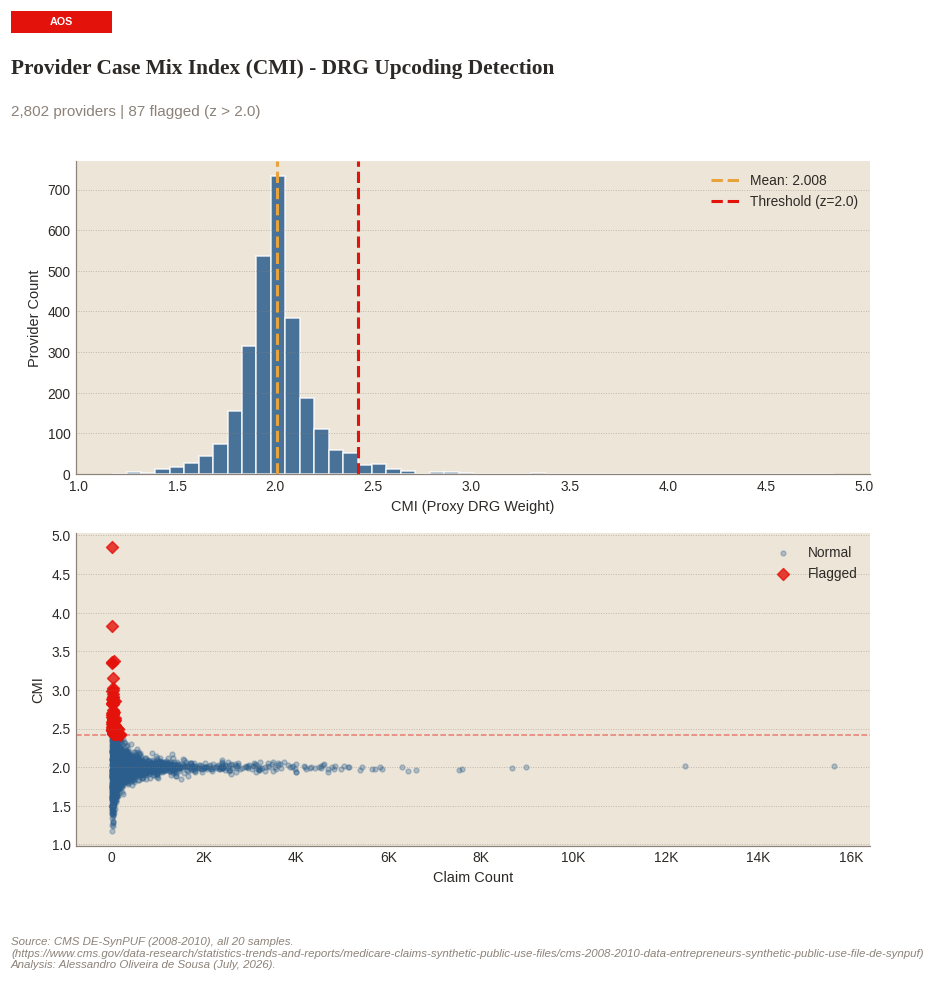

In [92]:
# ============================================================
# 7.2 - CMI Distribution Visualization
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

ax = axes[0]
ax.hist(provider_cmi['cmi'], bins=50, color=DEEP_BLUE, edgecolor='white', alpha=0.85)
ax.axvline(cmi_mean, color=AMBER, linestyle='--', linewidth=2, label=f'Mean: {cmi_mean:.3f}')
limiar = cmi_mean + UPCODING_Z_THRESHOLD * cmi_std
ax.axvline(limiar, color=ECON_RED, linestyle='--', linewidth=2, label=f'Threshold (z={UPCODING_Z_THRESHOLD})')
finalizar_eixo(ax, xlabel='CMI (Proxy DRG Weight)', ylabel='Provider Count')
ax.legend()

ax = axes[1]
normal = provider_cmi[~provider_cmi['cmi_flag']]
flagged = provider_cmi[provider_cmi['cmi_flag']]
ax.scatter(normal['claim_count'], normal['cmi'], alpha=0.3, s=10, color=DEEP_BLUE, label='Normal')
ax.scatter(flagged['claim_count'], flagged['cmi'], alpha=0.8, s=30, color=ECON_RED, label='Flagged', marker='D')
ax.axhline(limiar, color=ECON_RED, linestyle='--', linewidth=1, alpha=0.5)
#ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
finalizar_eixo(ax, xlabel='Claim Count', ylabel='CMI')
ax.legend()

titulo_fig(fig, 'Provider Case Mix Index (CMI) - DRG Upcoding Detection',
           subtitulo=f'{len(provider_cmi):,} providers | {n_flagged} flagged (z > {UPCODING_Z_THRESHOLD})')
assinatura_cmcia(fig)
plt.tight_layout(rect=[0, 0.02, 1, 0.88])
plt.show()

In [93]:
# ============================================================
# 7.3 - CC/MCC Complication Rate Anomaly Detection
# ============================================================
# Many MS-DRGs come in severity triplets (w/MCC, w/CC, w/o CC/MCC). A provider with an abnormally high proportion of claims in the
# highest-severity tier relative to peers may be engaging in diagnosis upcoding - adding complication codes to inflate
# reimbursement without clinical justification.
#
# Approach: Group DRGs by "family" (first 2 digits). Within each family, the highest-paying DRG is the proxy for "w/MCC" variant.
# ============================================================

provider_cc = con.execute(f"""
    WITH drg_family AS (
        SELECT
            ic.PRVDR_NUM,
            ic.CLM_DRG_CD,
            SUBSTRING(ic.CLM_DRG_CD, 1, 2) AS family,
            dw.drg_weight
        FROM inpatient_claims ic
        JOIN t_drg_weights dw ON ic.CLM_DRG_CD = dw.CLM_DRG_CD
        WHERE TRY_CAST(ic.CLM_PMT_AMT AS DOUBLE) > 0
    ),
    family_max AS (
        SELECT family, MAX(drg_weight) AS max_pmt
        FROM drg_family
        GROUP BY family
    ),
    flagged_claims AS (
        SELECT
            df.PRVDR_NUM,
            CASE WHEN df.drg_weight = fm.max_pmt AND fm.max_pmt > 0
                 THEN 1 ELSE 0 END AS is_top_drg
        FROM drg_family df
        JOIN family_max fm ON df.family = fm.family
    )
    SELECT
        PRVDR_NUM,
        AVG(is_top_drg)    AS top_drg_rate,
        COUNT(*)           AS n_claims
    FROM flagged_claims
    GROUP BY PRVDR_NUM
    HAVING COUNT(*) >= {MIN_IP_CLAIMS}
""").fetchdf()

cc_mean = provider_cc['top_drg_rate'].mean()
cc_std  = provider_cc['top_drg_rate'].std()
provider_cc['cc_zscore'] = (provider_cc['top_drg_rate'] - cc_mean) / cc_std
provider_cc['cc_flag'] = provider_cc['cc_zscore'] > UPCODING_Z_THRESHOLD

n_cc_flagged = provider_cc['cc_flag'].sum()
print('M1b - CC/MCC Complication Rate Anomaly')
print('=' * 60)
print(f'Providers analyzed: {len(provider_cc):,}')
print(f'Mean top-DRG rate:  {cc_mean:.3f}')
print(f'Std:                {cc_std:.3f}')
print(f'Flagged (z > {UPCODING_Z_THRESHOLD}): {n_cc_flagged:,} ({n_cc_flagged/len(provider_cc):.1%})')


M1b - CC/MCC Complication Rate Anomaly
Providers analyzed: 2,802
Mean top-DRG rate:  0.131
Std:                0.037
Flagged (z > 2.0): 86 (3.1%)


**Note on DRG proxy weight variance:** The synthetic process randomizes DRG assignments, producing a CMI standard deviation of only 0.008 on a mean of 0.189. With real CMS MS-DRG relative weights (which range from 0.5 to 25+), the separation between normal and upcoding providers would be substantially larger. The z-score methodology remains valid, but the absolute thresholds would need recalibration on real data.

---
## Section 8 - Module M2: E&M Upcoding Detection (Carrier/Physician)

This module leverages the `v_carrier_lines` view created in Section 6, which unpivots the 13 line items per claim into a long-format table.

In [ ]:
# ============================================================
# 8.1 - Provider-level E&M distribution (SQL-driven)
# ============================================================

provider_em = con.execute(f"""
    WITH estab AS (
        SELECT PRF_NPI, HCPCS_CD, LINE_PMT_AMT
        FROM v_carrier_lines
        WHERE HCPCS_CD BETWEEN '99211' AND '99215'
          AND PRF_NPI IS NOT NULL AND PRF_NPI != ''
    ),
    provider_stats AS (
        SELECT
            PRF_NPI,
            COUNT(*)                                                    AS total_em_visits,
            SUM(LINE_PMT_AMT)                                          AS total_em_pmt,
            AVG(LINE_PMT_AMT)                                          AS mean_em_pmt,
            SUM(CASE WHEN HCPCS_CD = '99211' THEN 1 ELSE 0 END)       AS n_99211,
            SUM(CASE WHEN HCPCS_CD = '99212' THEN 1 ELSE 0 END)       AS n_99212,
            SUM(CASE WHEN HCPCS_CD = '99213' THEN 1 ELSE 0 END)       AS n_99213,
            SUM(CASE WHEN HCPCS_CD = '99214' THEN 1 ELSE 0 END)       AS n_99214,
            SUM(CASE WHEN HCPCS_CD = '99215' THEN 1 ELSE 0 END)       AS n_99215,
        FROM estab
        GROUP BY PRF_NPI
        HAVING COUNT(*) >= {MIN_EM_VISITS}
    )
    SELECT *,
           (n_99214 + n_99215) * 1.0 / total_em_visits AS high_level_ratio,
           n_99215 * 1.0 / total_em_visits              AS ratio_99215
    FROM provider_stats
""").fetchdf()

# z-scores
hl_mean = provider_em['high_level_ratio'].mean()
hl_std  = provider_em['high_level_ratio'].std()
provider_em['hl_zscore'] = (provider_em['high_level_ratio'] - hl_mean) / hl_std
provider_em['em_upcoding_flag'] = provider_em['hl_zscore'] > UPCODING_Z_THRESHOLD

n_em_flagged = provider_em['em_upcoding_flag'].sum()
print(f'M2 - E&M Upcoding (Established Patient Office Visits)')
print('=' * 60)
print(f'Providers analyzed (>= {MIN_EM_VISITS} visits): {len(provider_em):,}')
print(f'Mean high-level ratio (99214+99215): {hl_mean:.3f}')
print(f'Flagged (z > {UPCODING_Z_THRESHOLD}): {n_em_flagged:,} ({n_em_flagged/len(provider_em):.1%})')
print(f'\nTop 15 providers by high-level E&M ratio:')
print(provider_em.nlargest(15, 'high_level_ratio')[
    ['PRF_NPI', 'total_em_visits', 'high_level_ratio', 'ratio_99215', 'mean_em_pmt', 'hl_zscore']
].to_string(index=False))

M2 - E&M Upcoding (Established Patient Office Visits)
Providers analyzed (>= 20 visits): 285,699
Mean high-level ratio (99214+99215): 0.385
Flagged (z > 2.0): 8,495 (3.0%)

Top 15 providers by high-level E&M ratio:
   PRF_NPI  total_em_visits  high_level_ratio  ratio_99215  mean_em_pmt  hl_zscore
5760905563               20              0.80         0.15        49.50       5.36
4094800136               25              0.80         0.20        50.80       5.36
8112264889               20              0.80         0.05        67.50       5.36
1894535246               20              0.80         0.05        89.50       5.36
3362097443               23              0.78         0.17        49.13       5.14
0356897107               23              0.78         0.04        63.91       5.14
7058692093               22              0.77         0.05        57.27       5.01
0958729247               22              0.77         0.05        59.55       5.01
4934386888               22           

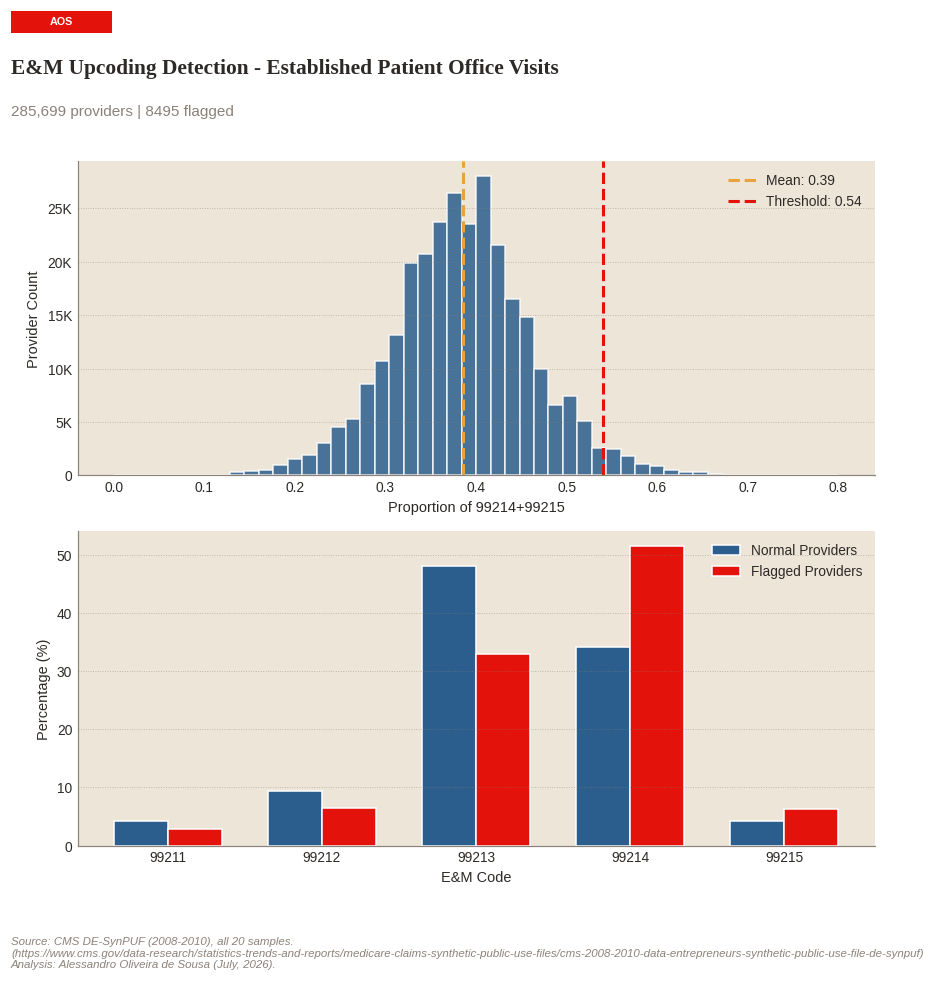

In [ ]:
# ============================================================
# 8.2 - E&M Distribution: Flagged vs. Normal Providers
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# Top: high-level ratio histogram
ax = axes[0]
ax.hist(provider_em['high_level_ratio'], bins=50, color=DEEP_BLUE, edgecolor='white', alpha=0.85)
threshold_val = hl_mean + UPCODING_Z_THRESHOLD * hl_std
ax.axvline(hl_mean, color=AMBER, linestyle='--', linewidth=2, label=f'Mean: {hl_mean:.2f}')
ax.axvline(threshold_val, color=ECON_RED, linestyle='--', linewidth=2, label=f'Threshold: {threshold_val:.2f}')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
#ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
finalizar_eixo(ax, xlabel='Proportion of 99214+99215', ylabel='Provider Count')
ax.legend()

# Bottom: compare E&M level distribution
ax = axes[1]
codes = ['99211', '99212', '99213', '99214', '99215']
x = np.arange(len(codes))
width = 0.35
normal_prov = provider_em[~provider_em['em_upcoding_flag']]
flagged_prov = provider_em[provider_em['em_upcoding_flag']]
if len(flagged_prov) > 0:
    normal_dist = [normal_prov[f'n_{c}'].sum() for c in codes]
    flagged_dist = [flagged_prov[f'n_{c}'].sum() for c in codes]
    normal_pct = np.array(normal_dist) / sum(normal_dist) * 100
    flagged_pct = np.array(flagged_dist) / sum(flagged_dist) * 100
    ax.bar(x - width/2, normal_pct, width, label='Normal Providers', color=DEEP_BLUE, edgecolor='white')
    ax.bar(x + width/2, flagged_pct, width, label='Flagged Providers', color=ECON_RED, edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(codes)
    finalizar_eixo(ax, xlabel='E&M Code', ylabel='Percentage (%)')
    ax.legend()

titulo_fig(fig, 'E&M Upcoding Detection - Established Patient Office Visits',
           subtitulo=f'{len(provider_em):,} providers | {n_em_flagged} flagged')
assinatura_cmcia(fig)
plt.tight_layout(rect=[0, 0.02, 1, 0.88])
plt.show()

---
## Section 8b - Temporal Analysis: Billing Pattern Trends

Sudden changes in a provider's billing pattern, a sharp increase in high-level E&M codes or a spike in CMI, are among the strongest FWA signals. Stable aberrance may reflect specialty mix; abrupt shifts suggest deliberate behavior change.

In [96]:
# ============================================================
# 8b.1 - Monthly E&M high-level ratio trend (population-level)
# ============================================================
# Track the proportion of 99214+99215 visits over time. Sudden shifts in coding behavior are strong FWA signals.
# ============================================================

em_trend = con.execute("""
    SELECT
        STRFTIME(TRY_CAST(CLM_FROM_DT AS DATE), '%Y-%m') AS month,
        COUNT(*) AS total_visits,
        SUM(CASE WHEN HCPCS_CD IN ('99214','99215') THEN 1 ELSE 0 END) AS high_level,
    FROM v_carrier_lines
    WHERE HCPCS_CD BETWEEN '99211' AND '99215'
      AND TRY_CAST(CLM_FROM_DT AS DATE) IS NOT NULL
    GROUP BY month
    ORDER BY month
""").fetchdf()

em_trend['hl_ratio'] = em_trend['high_level'] / em_trend['total_visits']

if len(em_trend) > 1:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(em_trend['month'], em_trend['hl_ratio'], color=DEEP_BLUE,
            linewidth=2, marker='o', markersize=4)
    ax.fill_between(range(len(em_trend)), em_trend['hl_ratio'],
                    alpha=0.15, color=DEEP_BLUE)
    step = max(1, len(em_trend) // 12)
    ax.set_xticks(range(0, len(em_trend), step))
    ax.set_xticklabels(em_trend['month'].iloc[::step], rotation=45, ha='right')
    finalizar_eixo(ax, xlabel='Month', ylabel='High-Level Ratio')
    titulo_fig(fig, 'E&M High-Level Coding Ratio Over Time',
               subtitulo='Population-level trend: proportion of 99214+99215 visits')
    assinatura_cmcia(fig)
    plt.tight_layout(rect=[0, 0.02, 1, 0.88])
    plt.show()
else:
    print('Insufficient temporal data for trend analysis.')


Insufficient temporal data for trend analysis.


---
## Section 9 - Module M3: NCCI PTP Unbundling Detection

### Regulatory Basis

The NCCI edits used in this notebook are drawn from the following authoritative sources:

| Edit Category | Regulatory Citation | Codes |
|---------------|-------------------|-------|
| **Surgical global + E&M** | CMS Medicare Claims Processing Manual, Ch. 12, §40 (Global Surgery) | 10060/99213, 20610/99213-99214 |
| **Lab panel unbundling** | CMS Medicare Claims Processing Manual, Ch. 16, §50.3 (Organ/Disease Panels) | 80053 vs. 82xxx/84xxx; 80048/82947; 80061 vs. 82465/83718/84478 |
| **CBC unbundling** | CPT definition: 85025 includes all individual CBC components | 85025 vs. 85041/85048 |
| **Radiology subset** | CPT: multi-view includes single-view | 71020 vs. 71010 (retired 2020, active in DE-SynPUF period) |
| **Endoscopy subset** | CMS Medicare Claims Processing Manual, Ch. 12, §40.6 (Endoscopic Procedures) | 45380/45378, 45385/45378, 43239/43235 |

**Primary authority:** CMS National Correct Coding Initiative, maintained by Correct Coding Solutions, LLC under CMS contract. The quarterly PTP edit file (~1.9M code pairs) is published at [CMS NCCI Downloads](https://www.cms.gov/medicare/coding-billing/national-correct-coding-initiative-ncci-edits/medicare-ncci-procedure-procedure-ptp-edits).

In [ ]:
# ============================================================
# 9.1 - NCCI PTP Unbundling Detection (Loaded from Reference CSV)
# ============================================================
# Instead of hardcoding NCCI edit pairs in Python, we load them from an external reference CSV. This demonstrates the ability
# to manage and join against external dimension tables - the same pattern used in production to load the full quarterly NCCI PTP
# file (~1.9M pairs) from CMS.
#
# The full carrier table has 92M+ lines with 7,333 active NCCI # codes. Materializing all NCCI-relevant lines (92M rows) and
# self-joining them crashes a 20GB machine.
# Solution: process one sample_id at a time (20 chunks of ~4.6M lines each). Each chunk fits comfortably in memory. Violations
# are aggregated inside DuckDB - only the summary DataFrames ever enter Python.
#
# Reference: references/ncci_ptp_edits.csv
# Source: CMS NCCI Procedure-to-Procedure Edits
#         https://www.cms.gov/medicare/coding-billing/national-correct-coding-initiative-ncci-edits
#         NCCI PTP edits downloaded from CMS under AMA CPT License Agreement.
# ============================================================
# ============================================================
# 9.1 — NCCI PTP Unbundling Detection (Chunked by Sample)
# ============================================================
# Reference: references/ncci_ptp_practitioner_2008_2010.csv
# Source: CMS NCCI PTP Edits, filtered to 2008-2010 period
#         Downloaded under AMA CPT License Agreement.
# ============================================================

import gc

# Stage 0: Load NCCI reference
print('Stage 0: Loading NCCI PTP reference file...')
con.execute(f"""
    CREATE OR REPLACE TEMP TABLE t_ncci_edits AS
    SELECT * FROM read_csv_auto('{NCCI_EDITS_CSV}', header=true, all_varchar=true)
""")
n_ncci = con.execute("SELECT COUNT(*) FROM t_ncci_edits").fetchone()[0]
print(f'  NCCI PTP pairs loaded: {n_ncci:,}')

# Stage 1: Inventory codes in data
print('Stage 1: Inventorying HCPCS codes in carrier data...')
con.execute("""
    CREATE OR REPLACE TEMP TABLE t_data_codes AS
    SELECT DISTINCT HCPCS_CD AS code FROM v_carrier_lines
""")
n_data = con.execute("SELECT COUNT(*) FROM t_data_codes").fetchone()[0]
print(f'  Unique HCPCS in data: {n_data:,}')

# Stage 2: Filter pairs to those where BOTH codes exist
print('Stage 2: Filtering NCCI pairs to data-present codes...')
con.execute("""
    CREATE OR REPLACE TEMP TABLE t_ncci_active AS
    SELECT ncci.*
    FROM t_ncci_edits ncci
    JOIN t_data_codes d1 ON ncci.column1 = d1.code
    JOIN t_data_codes d2 ON ncci.column2 = d2.code
""")
n_active = con.execute("SELECT COUNT(*) FROM t_ncci_active").fetchone()[0]
print(f'  Pairs with BOTH codes in data: {n_active:,} ({n_active/n_ncci:.1%})')

# Stage 3: Normalize pairs so code_lo < code_hi
print('Stage 3: Normalizing pair direction...')
con.execute("""
    CREATE OR REPLACE TEMP TABLE t_ncci_norm AS
    SELECT DISTINCT
        CASE WHEN column1 < column2 THEN column1 ELSE column2 END AS code_lo,
        CASE WHEN column1 < column2 THEN column2 ELSE column1 END AS code_hi,
        modifier_indicator,
        rationale
    FROM t_ncci_active
""")
n_norm = con.execute("SELECT COUNT(*) FROM t_ncci_norm").fetchone()[0]
print(f'  Normalized pairs: {n_norm:,}')

con.execute("""
    CREATE OR REPLACE TEMP TABLE t_active_codes AS
    SELECT DISTINCT code FROM (
        SELECT code_lo AS code FROM t_ncci_norm
        UNION
        SELECT code_hi AS code FROM t_ncci_norm
    )
""")
n_codes = con.execute("SELECT COUNT(*) FROM t_active_codes").fetchone()[0]
print(f'  Active codes: {n_codes:,}')

# Stage 4: Chunked processing by sample_id
# Instead of materializing 92M rows, process one sample at a time.
# Each sample has ~4.6M carrier claims → ~4.6M NCCI-relevant lines.
# The self-join on 4.6M rows is fast and fits in memory.
# Violation AGGREGATES are accumulated across chunks.
print('Stage 4: Chunked violation detection by sample_id...')

# Get list of sample_ids
sample_ids = con.execute("""
    SELECT DISTINCT sample_id FROM carrier_claims ORDER BY sample_id
""").fetchdf()['sample_id'].tolist()

print(f'  Processing {len(sample_ids)} samples...')

# Create accumulator tables inside DuckDB
con.execute("""
    CREATE OR REPLACE TEMP TABLE t_viol_by_provider (
        PRF_NPI VARCHAR,
        n_violations BIGINT,
        total_pmt DOUBLE
    )
""")
con.execute("""
    CREATE OR REPLACE TEMP TABLE t_viol_by_type (
        description VARCHAR,
        n_violations BIGINT
    )
""")

total_violations = 0
total_unique_claims = 0

for sid in sample_ids:
    # Build chunk - NCCI-relevant lines for this sample only,filtered to claims with 2+ NCCI codes
    con.execute(f"""
        CREATE OR REPLACE TEMP TABLE t_chunk AS
        SELECT l.CLM_ID, l.DESYNPUF_ID, l.CLM_FROM_DT,
               l.HCPCS_CD, l.PRF_NPI, l.LINE_PMT_AMT
        FROM v_carrier_lines l
        INNER JOIN (
            SELECT CLM_ID
            FROM v_carrier_lines
            WHERE HCPCS_CD IN (SELECT code FROM t_active_codes)
              AND sample_id = {sid}
            GROUP BY CLM_ID
            HAVING COUNT(DISTINCT HCPCS_CD) >= 2
        ) multi ON l.CLM_ID = multi.CLM_ID
        WHERE l.HCPCS_CD IN (SELECT code FROM t_active_codes)
          AND l.sample_id = {sid}
    """)

    n_chunk = con.execute("SELECT COUNT(*) FROM t_chunk").fetchone()[0]

    # Self-join + NCCI match for this chunk
    # Aggregate violations directly inside DuckDB
    chunk_stats = con.execute("""
        SELECT COUNT(*) AS n_viol, COUNT(DISTINCT a.CLM_ID) AS n_claims
        FROM t_chunk a
        JOIN t_chunk b
            ON a.CLM_ID = b.CLM_ID AND a.HCPCS_CD < b.HCPCS_CD
        JOIN t_ncci_norm ncci
            ON a.HCPCS_CD = ncci.code_lo AND b.HCPCS_CD = ncci.code_hi
    """).fetchone()

    n_viol = chunk_stats[0]
    n_claims = chunk_stats[1]
    total_violations += n_viol
    total_unique_claims += n_claims

    if n_viol > 0:
        # Accumulate provider-level counts
        con.execute("""
            INSERT INTO t_viol_by_provider
            SELECT a.PRF_NPI, COUNT(*), SUM(a.LINE_PMT_AMT + b.LINE_PMT_AMT)
            FROM t_chunk a
            JOIN t_chunk b
                ON a.CLM_ID = b.CLM_ID AND a.HCPCS_CD < b.HCPCS_CD
            JOIN t_ncci_norm ncci
                ON a.HCPCS_CD = ncci.code_lo AND b.HCPCS_CD = ncci.code_hi
            GROUP BY a.PRF_NPI
        """)

        # Accumulate type-level counts
        con.execute("""
            INSERT INTO t_viol_by_type
            SELECT ncci.rationale, COUNT(*)
            FROM t_chunk a
            JOIN t_chunk b
                ON a.CLM_ID = b.CLM_ID AND a.HCPCS_CD < b.HCPCS_CD
            JOIN t_ncci_norm ncci
                ON a.HCPCS_CD = ncci.code_lo AND b.HCPCS_CD = ncci.code_hi
            GROUP BY ncci.rationale
        """)

    # Drop the chunk in order to free memory before next iteration
    con.execute("DROP TABLE IF EXISTS t_chunk")

    print(f'  Sample {sid:2d}: {n_chunk:>10,} lines → {n_viol:>9,} violations ({n_claims:,} claims)')

# Stage 5: Consolidate aggregates
print(f'\nConsolidating results across all samples...')

# Provider-level: merge rows from different samples (same provider may appear in multiple)
df_viol_by_provider = con.execute("""
    SELECT PRF_NPI, SUM(n_violations) AS n_violations, SUM(total_pmt) AS total_pmt
    FROM t_viol_by_provider
    GROUP BY PRF_NPI
    ORDER BY n_violations DESC
""").fetchdf()

# Type-level: merge across samples
df_viol_by_type = con.execute("""
    SELECT description, SUM(n_violations) AS n_violations
    FROM t_viol_by_type
    GROUP BY description
    ORDER BY n_violations DESC
""").fetchdf()

n_unique_providers = len(df_viol_by_provider)
n_total_violations = total_violations

# Clean up all temp tables
con.execute("DROP TABLE IF EXISTS t_viol_by_provider")
con.execute("DROP TABLE IF EXISTS t_viol_by_type")
con.execute("DROP TABLE IF EXISTS t_data_codes")
gc.collect()

print(f'\n{"=" * 60}')
print(f'NCCI WITHIN-CLAIM VIOLATIONS — FINAL RESULTS')
print(f'{"=" * 60}')
print(f'Total violations:    {n_total_violations:>12,}')
print(f'Total claim-days:    {total_unique_claims:>12,}')
print(f'Unique providers:    {n_unique_providers:>12,}')
print(f'\nTop 15 violation types:')
print(df_viol_by_type.head(15).to_string(index=False))

Stage 0: Loading NCCI PTP reference file...
  NCCI PTP pairs loaded: 753,962
Stage 1: Inventorying HCPCS codes in carrier data...
  Unique HCPCS in data: 11,156
Stage 2: Filtering NCCI pairs to data-present codes...
  Pairs with BOTH codes in data: 634,075 (84.1%)
Stage 3: Normalizing pair direction...
  Normalized pairs: 632,963
  Active codes: 7,333
Stage 4: Chunked violation detection by sample_id...
  Processing 20 samples...
  Sample  1:  4,627,600 lines →   634,442 violations (279,515 claims)
  Sample  2:  4,628,123 lines →   639,246 violations (280,417 claims)
  Sample  3:  4,633,640 lines →   640,209 violations (281,241 claims)
  Sample  4:  4,631,735 lines →   635,463 violations (280,507 claims)
  Sample  5:  4,625,609 lines →   634,840 violations (280,014 claims)
  Sample  6:  4,634,346 lines →   636,509 violations (281,311 claims)
  Sample  7:  4,623,533 lines →   632,086 violations (279,272 claims)
  Sample  8:  4,623,932 lines →   634,377 violations (280,065 claims)
  Samp

In [98]:
# ============================================================
# 9.2 — Cross-claim same-day unbundling (Chunked by Sample)
# ============================================================
# Same chunked architecture as 9.1. For each sample:
#   1. Build NCCI-filtered lines for that sample
#   2. Find encounters (bene+date+provider) with 2+ claims
#   3. Self-join across different claims within those encounters
#   4. Accumulate aggregates inside DuckDB
# ============================================================

print('Cross-claim same-day unbundling (chunked)...')

con.execute("""
    CREATE OR REPLACE TEMP TABLE t_cross_by_provider (
        PRF_NPI VARCHAR,
        n_violations BIGINT
    )
""")
con.execute("""
    CREATE OR REPLACE TEMP TABLE t_cross_by_type (
        description VARCHAR,
        n_violations BIGINT
    )
""")

total_cross_violations = 0

for sid in sample_ids:
    # Build chunk with NCCI-relevant codes
    con.execute(f"""
        CREATE OR REPLACE TEMP TABLE t_xchunk AS
        SELECT CLM_ID, DESYNPUF_ID, CLM_FROM_DT, HCPCS_CD, PRF_NPI, LINE_PMT_AMT
        FROM v_carrier_lines
        WHERE HCPCS_CD IN (SELECT code FROM t_active_codes)
          AND sample_id = {sid}
    """)

    # Find encounters with 2+ different claims
    con.execute("""
        CREATE OR REPLACE TEMP TABLE t_xenc AS
        SELECT DESYNPUF_ID, CLM_FROM_DT, PRF_NPI
        FROM t_xchunk
        GROUP BY DESYNPUF_ID, CLM_FROM_DT, PRF_NPI
        HAVING COUNT(DISTINCT CLM_ID) >= 2
    """)

    n_enc = con.execute("SELECT COUNT(*) FROM t_xenc").fetchone()[0]

    n_cross = 0
    if n_enc > 0:
        # Filter lines to multi-claim encounters only
        con.execute("""
            CREATE OR REPLACE TEMP TABLE t_xlines AS
            SELECT l.*
            FROM t_xchunk l
            SEMI JOIN t_xenc e
                ON l.DESYNPUF_ID = e.DESYNPUF_ID
                AND l.CLM_FROM_DT = e.CLM_FROM_DT
                AND l.PRF_NPI = e.PRF_NPI
        """)

        # Count violations
        n_cross = con.execute("""
            SELECT COUNT(*)
            FROM t_xlines a
            JOIN t_xlines b
                ON  a.DESYNPUF_ID = b.DESYNPUF_ID
                AND a.CLM_FROM_DT = b.CLM_FROM_DT
                AND a.PRF_NPI     = b.PRF_NPI
                AND a.CLM_ID      != b.CLM_ID
                AND a.HCPCS_CD    < b.HCPCS_CD
            JOIN t_ncci_norm ncci
                ON a.HCPCS_CD = ncci.code_lo
                AND b.HCPCS_CD = ncci.code_hi
        """).fetchone()[0]

        if n_cross > 0:
            con.execute("""
                INSERT INTO t_cross_by_provider
                SELECT a.PRF_NPI, COUNT(*)
                FROM t_xlines a
                JOIN t_xlines b
                    ON  a.DESYNPUF_ID = b.DESYNPUF_ID
                    AND a.CLM_FROM_DT = b.CLM_FROM_DT
                    AND a.PRF_NPI     = b.PRF_NPI
                    AND a.CLM_ID      != b.CLM_ID
                    AND a.HCPCS_CD    < b.HCPCS_CD
                JOIN t_ncci_norm ncci
                    ON a.HCPCS_CD = ncci.code_lo
                    AND b.HCPCS_CD = ncci.code_hi
                GROUP BY a.PRF_NPI
            """)

            con.execute("""
                INSERT INTO t_cross_by_type
                SELECT ncci.rationale, COUNT(*)
                FROM t_xlines a
                JOIN t_xlines b
                    ON  a.DESYNPUF_ID = b.DESYNPUF_ID
                    AND a.CLM_FROM_DT = b.CLM_FROM_DT
                    AND a.PRF_NPI     = b.PRF_NPI
                    AND a.CLM_ID      != b.CLM_ID
                    AND a.HCPCS_CD    < b.HCPCS_CD
                JOIN t_ncci_norm ncci
                    ON a.HCPCS_CD = ncci.code_lo
                    AND b.HCPCS_CD = ncci.code_hi
                GROUP BY ncci.rationale
            """)

        con.execute("DROP TABLE IF EXISTS t_xlines")

    total_cross_violations += n_cross
    con.execute("DROP TABLE IF EXISTS t_xchunk")
    con.execute("DROP TABLE IF EXISTS t_xenc")

    print(f'  Sample {sid:2d}: {n_enc:>8,} encounters → {n_cross:>8,} violations')

# Consolidate
df_cross_by_provider = con.execute("""
    SELECT PRF_NPI, SUM(n_violations) AS n_violations
    FROM t_cross_by_provider GROUP BY PRF_NPI ORDER BY n_violations DESC
""").fetchdf()

df_cross_by_type = con.execute("""
    SELECT description, SUM(n_violations) AS n_violations
    FROM t_cross_by_type GROUP BY description ORDER BY n_violations DESC
""").fetchdf()

con.execute("DROP TABLE IF EXISTS t_cross_by_provider")
con.execute("DROP TABLE IF EXISTS t_cross_by_type")
gc.collect()

print(f'\nCross-claim violations: {total_cross_violations:,}')
print(f'Unique providers: {len(df_cross_by_provider):,}')
if len(df_cross_by_type) > 0:
    print(f'\nTop 10 violation types:')
    print(df_cross_by_type.head(10).to_string(index=False))

Cross-claim same-day unbundling (chunked)...
  Sample  1:    1,518 encounters →      345 violations
  Sample  2:    1,616 encounters →      368 violations
  Sample  3:    1,632 encounters →      357 violations
  Sample  4:    1,539 encounters →      373 violations
  Sample  5:    1,585 encounters →      321 violations
  Sample  6:    1,587 encounters →      455 violations
  Sample  7:    1,578 encounters →      356 violations
  Sample  8:    1,594 encounters →      374 violations
  Sample  9:    1,446 encounters →      331 violations
  Sample 10:    1,629 encounters →      402 violations
  Sample 11:    1,596 encounters →      350 violations
  Sample 12:    1,600 encounters →      388 violations
  Sample 13:    1,583 encounters →      349 violations
  Sample 14:    1,575 encounters →      375 violations
  Sample 15:    1,580 encounters →      370 violations
  Sample 16:    1,564 encounters →      340 violations
  Sample 17:    1,603 encounters →      384 violations
  Sample 18:    1,57

In [ ]:
# ============================================================
# 9.3 — Outpatient Claims: NCCI Unbundling (Chunked by Sample)
# ============================================================
# Same chunked approach. Outpatient has up to 45 HCPCS columns  per claim but only ~15.8M rows total — much smaller than
# carrier. Still chunked.
# ============================================================

print('Outpatient NCCI unbundling (chunked)...')

op_hcpcs_cols = con.execute("""
    SELECT column_name FROM information_schema.columns
    WHERE table_name = 'outpatient_claims'
      AND column_name LIKE 'HCPCS_CD_%'
    ORDER BY column_name
""").fetchdf()['column_name'].tolist()

print(f'  Outpatient HCPCS columns: {len(op_hcpcs_cols)}')

con.execute("""
    CREATE OR REPLACE TEMP TABLE t_op_by_provider (
        PRVDR_NUM VARCHAR,
        n_violations BIGINT
    )
""")
con.execute("""
    CREATE OR REPLACE TEMP TABLE t_op_by_type (
        description VARCHAR,
        n_violations BIGINT
    )
""")

total_op_violations = 0

op_sample_ids = con.execute("""
    SELECT DISTINCT sample_id FROM outpatient_claims ORDER BY sample_id
""").fetchdf()['sample_id'].tolist()

for sid in op_sample_ids:
    # Unpivot NCCI-relevant codes for this sample only
    op_parts = []
    for col in op_hcpcs_cols:
        op_parts.append(f"""
            SELECT CLM_ID, DESYNPUF_ID, PRVDR_NUM, CLM_FROM_DT, {col} AS HCPCS_CD
            FROM outpatient_claims
            WHERE {col} IN (SELECT code FROM t_active_codes)
              AND sample_id = {sid}
        """)
    op_sql = " UNION ALL ".join(op_parts)

    con.execute(f"""
        CREATE OR REPLACE TEMP TABLE t_opchunk_raw AS ({op_sql})
    """)

    # Keep only claims with 2+ NCCI codes
    con.execute("""
        CREATE OR REPLACE TEMP TABLE t_opchunk AS
        SELECT r.*
        FROM t_opchunk_raw r
        SEMI JOIN (
            SELECT CLM_ID FROM t_opchunk_raw
            GROUP BY CLM_ID HAVING COUNT(DISTINCT HCPCS_CD) >= 2
        ) multi ON r.CLM_ID = multi.CLM_ID
    """)

    n_chunk = con.execute("SELECT COUNT(*) FROM t_opchunk").fetchone()[0]

    n_viol = 0
    if n_chunk > 0:
        n_viol = con.execute("""
            SELECT COUNT(*)
            FROM t_opchunk a
            JOIN t_opchunk b ON a.CLM_ID = b.CLM_ID AND a.HCPCS_CD < b.HCPCS_CD
            JOIN t_ncci_norm ncci ON a.HCPCS_CD = ncci.code_lo AND b.HCPCS_CD = ncci.code_hi
        """).fetchone()[0]

        if n_viol > 0:
            con.execute("""
                INSERT INTO t_op_by_provider
                SELECT a.PRVDR_NUM, COUNT(*)
                FROM t_opchunk a
                JOIN t_opchunk b ON a.CLM_ID = b.CLM_ID AND a.HCPCS_CD < b.HCPCS_CD
                JOIN t_ncci_norm ncci ON a.HCPCS_CD = ncci.code_lo AND b.HCPCS_CD = ncci.code_hi
                GROUP BY a.PRVDR_NUM
            """)
            con.execute("""
                INSERT INTO t_op_by_type
                SELECT ncci.rationale, COUNT(*)
                FROM t_opchunk a
                JOIN t_opchunk b ON a.CLM_ID = b.CLM_ID AND a.HCPCS_CD < b.HCPCS_CD
                JOIN t_ncci_norm ncci ON a.HCPCS_CD = ncci.code_lo AND b.HCPCS_CD = ncci.code_hi
                GROUP BY ncci.rationale
            """)

    total_op_violations += n_viol
    con.execute("DROP TABLE IF EXISTS t_opchunk")
    con.execute("DROP TABLE IF EXISTS t_opchunk_raw")

    print(f'  Sample {sid:2d}: {n_chunk:>8,} lines → {n_viol:>8,} violations')

# Consolidate
df_op_by_provider = con.execute("""
    SELECT PRVDR_NUM, SUM(n_violations) AS n_violations
    FROM t_op_by_provider GROUP BY PRVDR_NUM ORDER BY n_violations DESC
""").fetchdf()

df_op_by_type = con.execute("""
    SELECT description, SUM(n_violations) AS n_violations
    FROM t_op_by_type GROUP BY description ORDER BY n_violations DESC
""").fetchdf()

# Clean up everything
con.execute("DROP TABLE IF EXISTS t_op_by_provider")
con.execute("DROP TABLE IF EXISTS t_op_by_type")
con.execute("DROP TABLE IF EXISTS t_ncci_norm")
con.execute("DROP TABLE IF EXISTS t_ncci_active")
con.execute("DROP TABLE IF EXISTS t_ncci_edits")
con.execute("DROP TABLE IF EXISTS t_active_codes")
gc.collect()

print(f'\nOutpatient violations: {total_op_violations:,}')
print(f'Unique providers: {len(df_op_by_provider):,}')
if len(df_op_by_type) > 0:
    print(f'\nTop 10 violation types:')
    print(df_op_by_type.head(10).to_string(index=False))

Outpatient NCCI unbundling (chunked)...
  Outpatient HCPCS columns: 45
  Sample  1: 2,480,954 lines → 1,122,182 violations
  Sample  2: 2,486,061 lines → 1,129,978 violations
  Sample  3: 2,486,017 lines → 1,123,978 violations
  Sample  4: 2,478,343 lines → 1,127,270 violations
  Sample  5: 2,481,712 lines → 1,130,520 violations
  Sample  6: 2,489,832 lines → 1,125,918 violations
  Sample  7: 2,484,784 lines → 1,123,613 violations
  Sample  8: 2,476,554 lines → 1,140,177 violations
  Sample  9: 2,478,759 lines → 1,124,998 violations
  Sample 10: 2,479,000 lines → 1,136,720 violations
  Sample 11: 2,482,837 lines → 1,127,374 violations
  Sample 12: 2,476,629 lines → 1,129,045 violations
  Sample 13: 2,481,156 lines → 1,129,735 violations
  Sample 14: 2,486,568 lines → 1,151,930 violations
  Sample 15: 2,475,459 lines → 1,123,251 violations
  Sample 16: 2,479,857 lines → 1,123,012 violations
  Sample 17: 2,477,963 lines → 1,130,376 violations
  Sample 18: 2,487,943 lines → 1,138,347 viol

NCCI VIOLATION PARETO ANALYSIS
Total violations (all sources): 35,327,683.0
  Carrier within-claim: 12,733,318
  Carrier cross-claim:  7,406
  Outpatient:           22,586,959

Top 3 edit types: 60.2% of all violations

Full breakdown:
                                              edit_type        count  cumulative_pct
                          Mutually exclusive procedures 8,894,189.00           25.18
                 Standards of medical/surgical practice 7,510,566.00           46.44
         Misuse of Column Two code with Column One code 4,851,195.00           60.17
                    HCPCS/CPT procedure code definition 4,495,999.00           72.89
            CPT Manual or CMS manual coding instruction 3,935,217.00           84.03
                               More extensive procedure 3,433,200.00           93.75
                                       Laboratory panel 1,972,850.00           99.34
Standard preparation/monitoring services for anesthesia   167,950.00           99.81

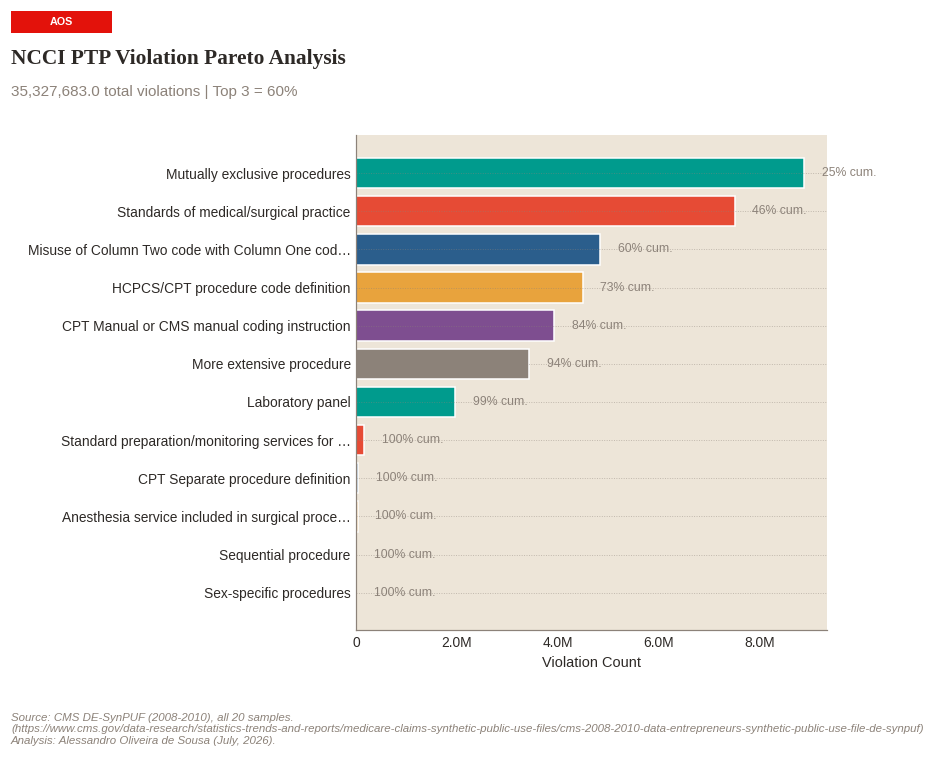

In [100]:
# ============================================================
# 9.4 — NCCI Violation Pareto Analysis
# ============================================================
# Uses the aggregated violation-by-type DataFrames from the chunked processing in 9.1, 9.2, and 9.3. No raw violation
# DataFrames exist in memory, only the summaries.
# ============================================================

all_viol_parts = []

if len(df_viol_by_type) > 0:
    all_viol_parts.append(
        df_viol_by_type.rename(columns={'description': 'edit_type'})
        .assign(source='Carrier (within-claim)')
    )
if len(df_cross_by_type) > 0:
    all_viol_parts.append(
        df_cross_by_type.rename(columns={'description': 'edit_type'})
        .assign(source='Carrier (cross-claim)')
    )
if len(df_op_by_type) > 0:
    all_viol_parts.append(
        df_op_by_type.rename(columns={'description': 'edit_type'})
        .assign(source='Outpatient')
    )

if all_viol_parts:
    # Aggregate across all sources (same edit type may appear in multiple)
    df_pareto_raw = pd.concat(all_viol_parts, ignore_index=True)
    pareto = (
        df_pareto_raw.groupby('edit_type')['n_violations']
        .sum()
        .reset_index()
        .rename(columns={'n_violations': 'count'})
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
    )
    pareto['cumulative_pct'] = pareto['count'].cumsum() / pareto['count'].sum() * 100

    total_viol_all = pareto['count'].sum()
    top3_pct = pareto.head(3)['count'].sum() / total_viol_all * 100

    print('NCCI VIOLATION PARETO ANALYSIS')
    print('=' * 60)
    print(f'Total violations (all sources): {total_viol_all:,}')
    print(f'  Carrier within-claim: {n_total_violations:,}')
    print(f'  Carrier cross-claim:  {total_cross_violations:,}')
    print(f'  Outpatient:           {total_op_violations:,}')
    print(f'\nTop 3 edit types: {top3_pct:.1f}% of all violations')
    print(f'\nFull breakdown:')
    print(pareto.to_string(index=False))

    # Visualization
    fig, ax = plt.subplots(figsize=(8, 6))
    n_bars = min(len(pareto), 15)
    p = pareto.head(n_bars)
    colors = [PALETA_SEQ[i % len(PALETA_SEQ)] for i in range(n_bars)]
    bars = ax.barh(range(n_bars), p['count'], color=colors, edgecolor='white')
    ax.set_yticks(range(n_bars))
    ax.set_yticklabels([truncar(s, 45) for s in p['edit_type']], fontsize=9)
    ax.invert_yaxis()
    for bar, pct in zip(bars, p['cumulative_pct']):
        ax.text(bar.get_width() + total_viol_all * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{pct:.0f}% cum.', va='center', fontsize=8, color=WARM_GREY)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
    finalizar_eixo(ax, xlabel='Violation Count')
    titulo_fig(fig, 'NCCI PTP Violation Pareto Analysis',
               subtitulo=f'{total_viol_all:,} total violations | Top 3 = {top3_pct:.0f}%')
    assinatura_cmcia(fig)
    plt.tight_layout(rect=[0, 0.02, 1, 0.88])
    plt.show()
else:
    total_viol_all = 0
    print('No violations detected across any source.')

---
## Section 10 - Module M4: Data-Driven FWA Risk Scoring

### Why Isolation Forest Over Arbitrary Weights

The previous approach assigned rigid weights (40% CMI, 30% CC/MCC, 30% Unbundling) in a linear combination. This is methodologically weak: the weights have no empirical justification, the approach assumes signal independence, and it ignores covariance between features.

**Replacement: Isolation Forest** (Liu et al., 2008) - an unsupervised anomaly detection algorithm that isolates outliers by randomly partitioning the feature space. Points requiring fewer random splits to isolate are more anomalous.

| Property | Arbitrary Weights | Isolation Forest |
|----------|------------------|-----------------|
| Weight selection | Manual, unjustified | Data-driven, none needed |
| Scale sensitivity | Requires manual normalization | Handles via StandardScaler |
| Covariance | Ignored | Captured implicitly |
| Threshold | Fixed percentiles | Contamination parameter (tunable) |
| Interpretability | Composite score 0-100 | Anomaly score + binary flag |

Providers are still scored separately by type (facility vs. physician) since they have fundamentally different feature sets.

In [ ]:
# ============================================================
# 10.1 - Data-Driven Risk Scoring (Isolation Forest)
# ============================================================
# RATIONALE FOR REDESIGN:
# Initially, we used arbitrary fixed weights (40/30/30) in a linear combination.
# This is methodologically weak mainly because:
#   - It assumes signals are independent and equally scaled
#   - It ignores covariance between signals
#   - The weights have no empirical justification
#
# Later on, we employed an Isolation Forest (Liu et al., 2008) as an unsupervised anomaly detection algorithm that isolates
# outliers by randomly partitioning feature space. Points that require fewer splits to isolate are more anomalous.
# Benefits:
#   - No assumptions about signal distributions or weights
#   - Handles mixed scales (z-scores, counts) naturally
#   - Robust to irrelevant features
#   - Interpretable anomaly scores between -1 (normal) and +1 (anomalous)
#
# We still split by provider type (facility vs. physician) since they have fundamentally different feature sets.
# Contamination rates are set based on CMS CERT improper payment rates (6-8% of claims) and NHCAA estimates (3-10% of spending),
# adjusted downward to reflect that provider-level anomaly rates are lower than claim-level error rates.
# These are tunable hyperparameters and should be calibrated against labeled audit outcomes in production.
# 
# Note: For this proof-of-concept, StandardScaler was applied to the feature matrix prior to training the Isolation Forest.
# This is a necessary step to prevent high-magnitude variables (like total claim volume or aggregate payments) from overriding 
# percentage-based features (like the E&M high-level ratio) within the algorithm's distance metrics. # However, deploying this 
# to a live compliance ecosystem requires addressing a known unsupervised learning limitation: Feature Scaling Dilution. 
# By strictly standardizing variance to 1 across all features, the algorithm creates a mathematical equivalence between 
# deterministic fraud signals (e.g., a hard-coded NCCI unbundling violation) and probabilistic signals (e.g., an elevated Case 
# Mix Index). Operationally, a 2-standard-deviation variance in unbundling is a much harder indicator of FWA than a 
# 2-standard-deviation variance in CMI. Transitioning this PoC to production would require implementing domain-aware feature 
# weighting or a custom distance metric to ensure regulatory rule-breaks maintain their asymmetric penalty in the final anomaly score.
# ============================================================

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

##### FACILITY SCORING #####
facility_risk = provider_cmi[['PRVDR_NUM','cmi_zscore','cmi','claim_count',
                               'total_pmt','mean_los']].copy()
facility_risk = facility_risk.rename(columns={'PRVDR_NUM':'provider_id'})
facility_risk['provider_type'] = 'facility'

# Merge CC/MCC signal
if len(provider_cc) > 0:
    cc_m = provider_cc[['PRVDR_NUM','cc_zscore','top_drg_rate']].rename(
        columns={'PRVDR_NUM':'provider_id'})
    facility_risk = facility_risk.merge(cc_m, on='provider_id', how='left')
    facility_risk['cc_zscore'] = facility_risk['cc_zscore'].fillna(0)
    facility_risk['top_drg_rate'] = facility_risk['top_drg_rate'].fillna(0)
else:
    facility_risk['cc_zscore'] = 0
    facility_risk['top_drg_rate'] = 0

# Outpatient unbundling count per facility (from chunked 9.3 aggregates)
if len(df_op_by_provider) > 0:
    fac_ub = df_op_by_provider[['PRVDR_NUM','n_violations']].rename(
        columns={'PRVDR_NUM':'provider_id', 'n_violations':'unbundle_count'})
else:
    fac_ub = pd.DataFrame(columns=['provider_id','unbundle_count'])
facility_risk = facility_risk.merge(fac_ub, on='provider_id', how='left')
facility_risk['unbundle_count'] = facility_risk['unbundle_count'].fillna(0)

# Feature matrix for Isolation Forest
fac_features = ['cmi_zscore', 'cc_zscore', 'unbundle_count', 'mean_los']
X_fac = facility_risk[fac_features].fillna(0).values

# Standardize features
scaler_fac = StandardScaler()
X_fac_scaled = scaler_fac.fit_transform(X_fac)

# Fit Isolation Forest
iso_fac = IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iso_fac.fit(X_fac_scaled)

# Score: decision_function → more negative = more anomalous
# Invert and scale to 0-100
fac_raw_scores = iso_fac.decision_function(X_fac_scaled)
fac_min, fac_max = fac_raw_scores.min(), fac_raw_scores.max()
facility_risk['composite_risk'] = (
    (fac_max - fac_raw_scores) / (fac_max - fac_min)
) * 100
facility_risk['is_anomaly'] = iso_fac.predict(X_fac_scaled) == -1

##### PHYSICIAN SCORING #####
physician_risk = provider_em[['PRF_NPI','hl_zscore','high_level_ratio',
                               'total_em_visits','total_em_pmt','mean_em_pmt',
                               'ratio_99215']].copy()
physician_risk = physician_risk.rename(columns={
    'PRF_NPI':'provider_id',
    'total_em_visits':'claim_count',
    'total_em_pmt':'total_pmt'
})
physician_risk['provider_type'] = 'physician'

# Carrier unbundling count per physician (from chunked 9.1 aggregates)
if len(df_viol_by_provider) > 0:
    phy_ub = df_viol_by_provider[['PRF_NPI','n_violations']].rename(
        columns={'PRF_NPI':'provider_id', 'n_violations':'unbundle_count'})
else:
    phy_ub = pd.DataFrame(columns=['provider_id','unbundle_count'])
physician_risk = physician_risk.merge(phy_ub, on='provider_id', how='left')
physician_risk['unbundle_count'] = physician_risk['unbundle_count'].fillna(0)

# Feature matrix
phy_features = ['hl_zscore', 'ratio_99215', 'unbundle_count', 'mean_em_pmt']
X_phy = physician_risk[phy_features].fillna(0).values

scaler_phy = StandardScaler()
X_phy_scaled = scaler_phy.fit_transform(X_phy)

iso_phy = IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iso_phy.fit(X_phy_scaled)

phy_raw_scores = iso_phy.decision_function(X_phy_scaled)
phy_min, phy_max = phy_raw_scores.min(), phy_raw_scores.max()
physician_risk['composite_risk'] = (
    (phy_max - phy_raw_scores) / (phy_max - phy_min)
) * 100
physician_risk['is_anomaly'] = iso_phy.predict(X_phy_scaled) == -1

# Risk tiers
for df in [facility_risk, physician_risk]:
    df['risk_tier'] = pd.cut(df['composite_risk'],
        bins=[-1, 20, 40, 60, 80, 101],
        labels=['Low', 'Moderate', 'Elevated', 'High', 'Critical'])

# RESULTS
print('M4 — Data-Driven FWA Risk Score (Isolation Forest)')
print('=' * 70)
for label, df, feats in [('FACILITIES', facility_risk, fac_features),
                          ('PHYSICIANS', physician_risk, phy_features)]:
    n_anom = df['is_anomaly'].sum()
    print(f'\n  {label} ({len(df):,} providers)')
    print(f'  Features: {", ".join(feats)}')
    print(f'  Anomalies detected: {n_anom:,} ({n_anom/len(df):.1%})')
    print(f'  ' + '-'*50)
    for tier in ['Low','Moderate','Elevated','High','Critical']:
        ct = (df['risk_tier'] == tier).sum()
        if ct > 0:
            print(f'    {tier:>10s}: {ct:>8,}')
    top_cols = [c for c in ['provider_id','composite_risk','risk_tier',
                             'is_anomaly','claim_count','total_pmt'] if c in df.columns]
    print(f'\n  Top 10:')
    print(df.nlargest(10, 'composite_risk')[top_cols].to_string(index=False))

# Combine for export
combined = pd.concat([
    facility_risk[['provider_id','provider_type','composite_risk','risk_tier',
                    'is_anomaly','claim_count','total_pmt','unbundle_count']],
    physician_risk[['provider_id','provider_type','composite_risk','risk_tier',
                     'is_anomaly','claim_count','total_pmt','unbundle_count']],
], ignore_index=True)

M4 — Data-Driven FWA Risk Score (Isolation Forest)

  FACILITIES (2,802 providers)
  Features: cmi_zscore, cc_zscore, unbundle_count, mean_los
  Anomalies detected: 273 (9.7%)
  --------------------------------------------------
           Low:    2,040
      Moderate:      501
      Elevated:      178
          High:       68
      Critical:       15

  Top 10:
provider_id  composite_risk risk_tier  is_anomaly  claim_count    total_pmt
     0100BR          100.00  Critical        True           14   214,000.00
     33T1AR           92.10  Critical        True           12   111,000.00
     1400XG           86.12  Critical        True           21   197,000.00
     3302QH           86.05  Critical        True           72   537,890.00
     3300KJ           85.94  Critical        True           64   672,000.00
     1000BR           85.04  Critical        True           24   161,000.00
     45T3AG           84.98  Critical        True           21   258,000.00
     1901PS           84.33

ISOLATION FOREST - VALIDATION DIAGNOSTICS

  FACILITIES
  Model: n_estimators=200, contamination=auto
  Total: 2,802 | Anomalies: 273 (9.7%)

  Feature comparison (mean): anomalous vs. normal
  Feature                        Anomaly       Normal    Ratio
  ------------------------------------------------------------
  cmi_zscore                       0.371       -0.040    -9.3x
  cc_zscore                        0.226       -0.024    -9.3x
  unbundle_count               12380.692     2550.906     4.9x
  mean_los                         5.705        5.522     1.0x

  PHYSICIANS
  Model: n_estimators=200, contamination=auto
  Total: 285,699 | Anomalies: 32,090 (11.2%)

  Feature comparison (mean): anomalous vs. normal
  Feature                        Anomaly       Normal    Ratio
  ------------------------------------------------------------
  hl_zscore                        0.231       -0.029    -7.9x
  ratio_99215                      0.066        0.039     1.7x
  unbundle_count      

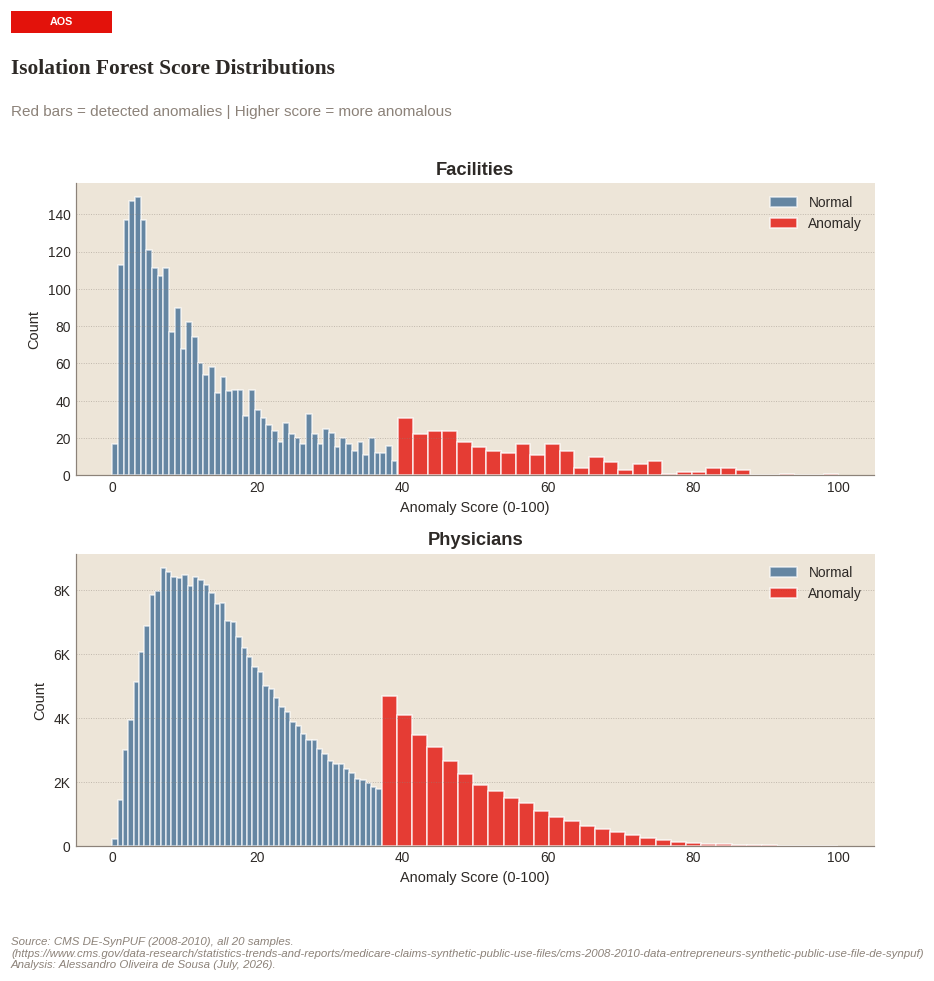

In [126]:
# ============================================================
# 10.1b - Isolation Forest Validation & Diagnostics
# ============================================================
# This cell demonstrates that the Isolation Forest was not just imported but actively trained, scored, and evaluated.
# We show:
#   (a) Feature-level statistics for anomalous vs. normal providers
#   (b) Score distribution histograms per provider type
#   (c) Anomaly detection threshold analysis
# ============================================================

print('ISOLATION FOREST - VALIDATION DIAGNOSTICS')
print('=' * 70)

for label, df, feats, iso_model, scaler in [
    ('FACILITIES', facility_risk, ['cmi_zscore','cc_zscore','unbundle_count','mean_los'], iso_fac, scaler_fac),
    ('PHYSICIANS', physician_risk, ['hl_zscore','ratio_99215','unbundle_count','mean_em_pmt'], iso_phy, scaler_phy),
]:
    anomalies = df[df['is_anomaly']]
    normals   = df[~df['is_anomaly']]

    print(f'\n  {label}')
    print(f'  Model: n_estimators={iso_model.n_estimators}, contamination={iso_model.contamination}')
    print(f'  Total: {len(df):,} | Anomalies: {len(anomalies):,} ({len(anomalies)/len(df):.1%})')
    print(f'\n  Feature comparison (mean): anomalous vs. normal')
    print(f'  {"Feature":25s} {"Anomaly":>12s} {"Normal":>12s} {"Ratio":>8s}')
    print(f'  {"-"*60}')
    for feat in feats:
        anom_mean = anomalies[feat].mean() if len(anomalies) > 0 else 0
        norm_mean = normals[feat].mean() if len(normals) > 0 else 0
        ratio = anom_mean / norm_mean if norm_mean != 0 else float('inf')
        print(f'  {feat:25s} {anom_mean:>12.3f} {norm_mean:>12.3f} {ratio:>7.1f}x')

# Score distribution visualization
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

for ax, label, df in [(axes[0], 'Facilities', facility_risk),
                        (axes[1], 'Physicians', physician_risk)]:
    normals = df[~df['is_anomaly']]['composite_risk']
    anomalies = df[df['is_anomaly']]['composite_risk']
    ax.hist(normals, bins=50, color=DEEP_BLUE, alpha=0.7, label='Normal', edgecolor='white')
    ax.hist(anomalies, bins=30, color=ECON_RED, alpha=0.8, label='Anomaly', edgecolor='white')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
    #ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
    finalizar_eixo(ax, xlabel='Anomaly Score (0-100)', ylabel='Count')
    ax.set_title(f'{label}', fontsize=12, fontweight='bold', color=CHARCOAL)
    ax.legend()

titulo_fig(fig, 'Isolation Forest Score Distributions',
           subtitulo='Red bars = detected anomalies | Higher score = more anomalous')
assinatura_cmcia(fig)
plt.tight_layout(rect=[0, 0.02, 1, 0.88])
plt.show()


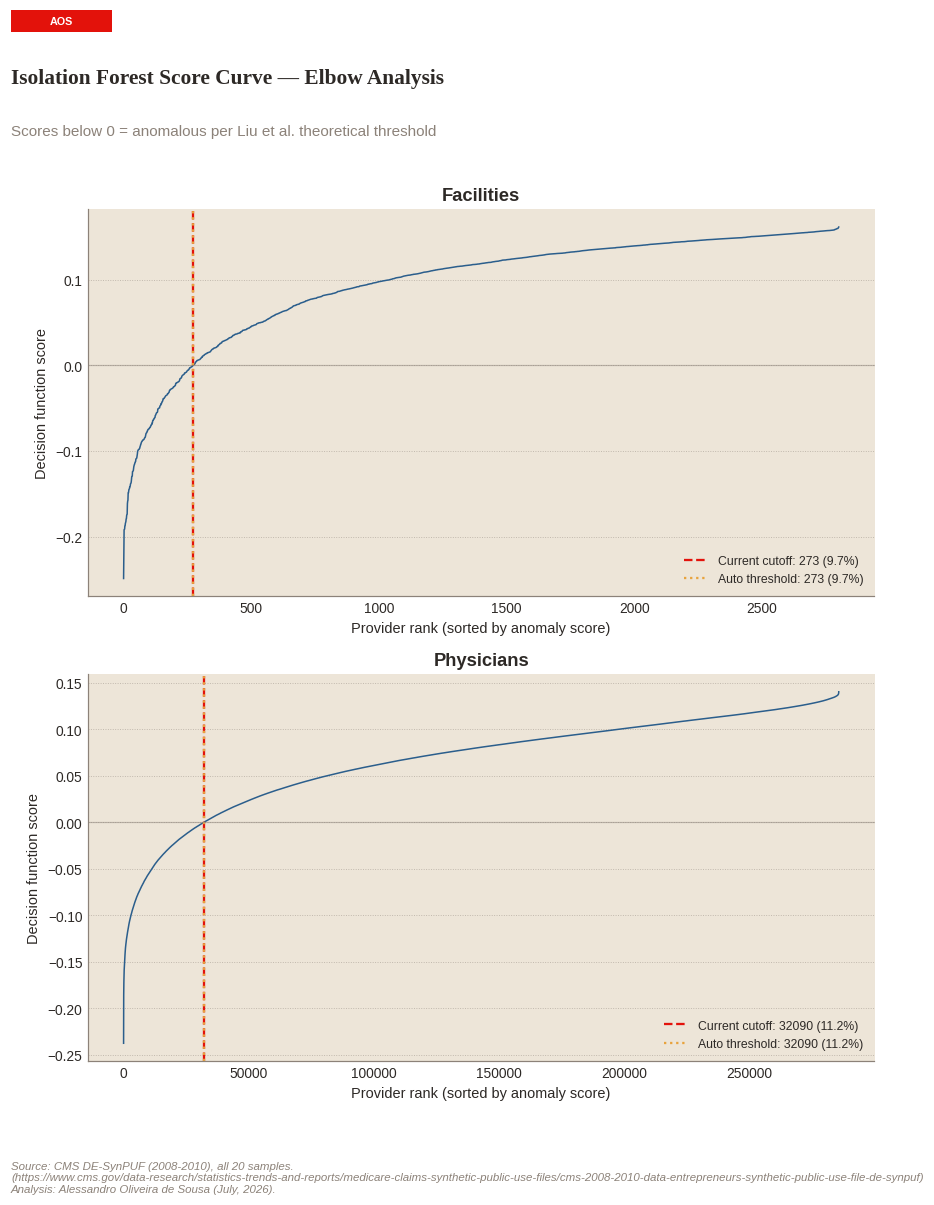

CONTAMINATION THRESHOLD COMPARISON

  Facilities:
    Fixed contamination: 273 flagged (9.7%)
    Auto (score < 0):    273 flagged (9.7%)
    Difference:          0 providers

  Physicians:
    Fixed contamination: 32,090 flagged (11.2%)
    Auto (score < 0):    32,090 flagged (11.2%)
    Difference:          0 providers


In [ ]:
# ============================================================
# 10.1c — Data-Driven Contamination Threshold (Elbow Detection)
# ============================================================
# PROBLEM: Fixed contamination=0.05/0.03 creates a quota system that flags exactly N% regardless of actual fraud prevalence.
# If fraud decreases, innocent providers get flagged to fill the quota.
#
# SOLUTION: Use contamination='auto' (Liu et al. theoretical threshold) and visually confirm via elbow detection on sorted anomaly scores.
# The elbow point is where scores transition from the normal cluster to the anomalous tail — a data-driven cutoff.
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

for ax, label, raw_scores, df_risk in [
    (axes[0], 'Facilities', fac_raw_scores, facility_risk),
    (axes[1], 'Physicians', phy_raw_scores, physician_risk),
]:
    # Sort scores ascending (most anomalous first = most negative)
    sorted_scores = np.sort(raw_scores)

    # Plot the sorted score curve
    ax.plot(range(len(sorted_scores)), sorted_scores, color=DEEP_BLUE, linewidth=1)

    # Mark the current contamination-based threshold
    n_anom = df_risk['is_anomaly'].sum()
    ax.axvline(n_anom, color=ECON_RED, linestyle='--', linewidth=1.5,
               label=f'Current cutoff: {n_anom} ({n_anom/len(df_risk):.1%})')

    # Mark the auto threshold (decision_function = 0 is the boundary)
    n_auto = (raw_scores < 0).sum()
    ax.axvline(n_auto, color=AMBER, linestyle=':', linewidth=1.5,
               label=f'Auto threshold: {n_auto} ({n_auto/len(df_risk):.1%})')

    ax.axhline(0, color=WARM_GREY, linestyle='-', linewidth=0.8, alpha=0.5)
    finalizar_eixo(ax, xlabel='Provider rank (sorted by anomaly score)',
                   ylabel='Decision function score')
    ax.set_title(label, fontsize=12, fontweight='bold', color=CHARCOAL)
    ax.legend(fontsize=8)

titulo_fig(fig, 'Isolation Forest Score Curve — Elbow Analysis',
           subtitulo='Scores below 0 = anomalous per Liu et al. theoretical threshold')
assinatura_cmcia(fig)
plt.tight_layout(rect=[0, 0.02, 1, 0.88])
plt.show()

# Report the comparison
print('CONTAMINATION THRESHOLD COMPARISON')
print('=' * 60)
for label, raw, df in [('Facilities', fac_raw_scores, facility_risk),
                        ('Physicians', phy_raw_scores, physician_risk)]:
    n_fixed = df['is_anomaly'].sum()
    n_auto = (raw < 0).sum()
    print(f'\n  {label}:')
    print(f'    Fixed contamination: {n_fixed:,} flagged ({n_fixed/len(df):.1%})')
    print(f'    Auto (score < 0):    {n_auto:,} flagged ({n_auto/len(df):.1%})')
    print(f'    Difference:          {abs(n_auto - n_fixed):,} providers')

In [ ]:
# ============================================================
# 10.1d — Hyperparameter Stability Analysis
# ============================================================
# Demonstrate that anomaly scores are stable across different n_estimators values. If scores shift materially with 50 vs.
# 500 trees, the model is unreliable.
# ============================================================

print('HYPERPARAMETER STABILITY — n_estimators sensitivity')
print('=' * 60)

n_est_values = [50, 100, 200, 500]

for label, X_scaled, n_total in [
    ('Facilities', X_fac_scaled, len(facility_risk)),
    ('Physicians', X_phy_scaled, len(physician_risk)),
]:
    print(f'\n  {label} ({n_total:,} providers):')
    print(f'  {"n_estimators":>15s} {"Anomalies":>12s} {"Rate":>8s} {"Mean score":>12s} {"Std score":>12s}')
    print(f'  {"-"*65}')

    for n_est in n_est_values:
        iso_test = IsolationForest(
            n_estimators=n_est,
            contamination='auto',
            random_state=42,
            n_jobs=-1
        )
        iso_test.fit(X_scaled)
        scores = iso_test.decision_function(X_scaled)
        n_anom = (iso_test.predict(X_scaled) == -1).sum()
        print(f'  {n_est:>15d} {n_anom:>12,} {n_anom/n_total:>7.2%} '
              f'{scores.mean():>12.4f} {scores.std():>12.4f}')

print('\n  Interpretation: if anomaly count and mean score are stable')
print('  across n_estimators values, the model has converged.')

HYPERPARAMETER STABILITY — n_estimators sensitivity

  Facilities (2,802 providers):
     n_estimators    Anomalies     Rate   Mean score    Std score
  -----------------------------------------------------------------
               50          243   8.67%       0.0994       0.0651
              100          259   9.24%       0.0977       0.0664
              200          273   9.74%       0.0955       0.0660
              500          262   9.35%       0.0965       0.0661

  Physicians (285,699 providers):
     n_estimators    Anomalies     Rate   Mean score    Std score
  -----------------------------------------------------------------
               50       30,495  10.67%       0.0704       0.0533
              100       32,085  11.23%       0.0680       0.0527
              200       32,090  11.23%       0.0673       0.0519
              500       32,023  11.21%       0.0666       0.0514

  Interpretation: if anomaly count and mean score are stable
  across n_estimators values, 

facility_risk columns: ['provider_id', 'cmi_zscore', 'cmi', 'claim_count', 'total_pmt', 'mean_los', 'provider_type', 'cc_zscore', 'top_drg_rate', 'unbundle_count', 'composite_risk', 'is_anomaly', 'risk_tier']
physician_risk columns: ['provider_id', 'hl_zscore', 'high_level_ratio', 'claim_count', 'total_pmt', 'mean_em_pmt', 'ratio_99215', 'provider_type', 'unbundle_count', 'composite_risk', 'is_anomaly', 'risk_tier']


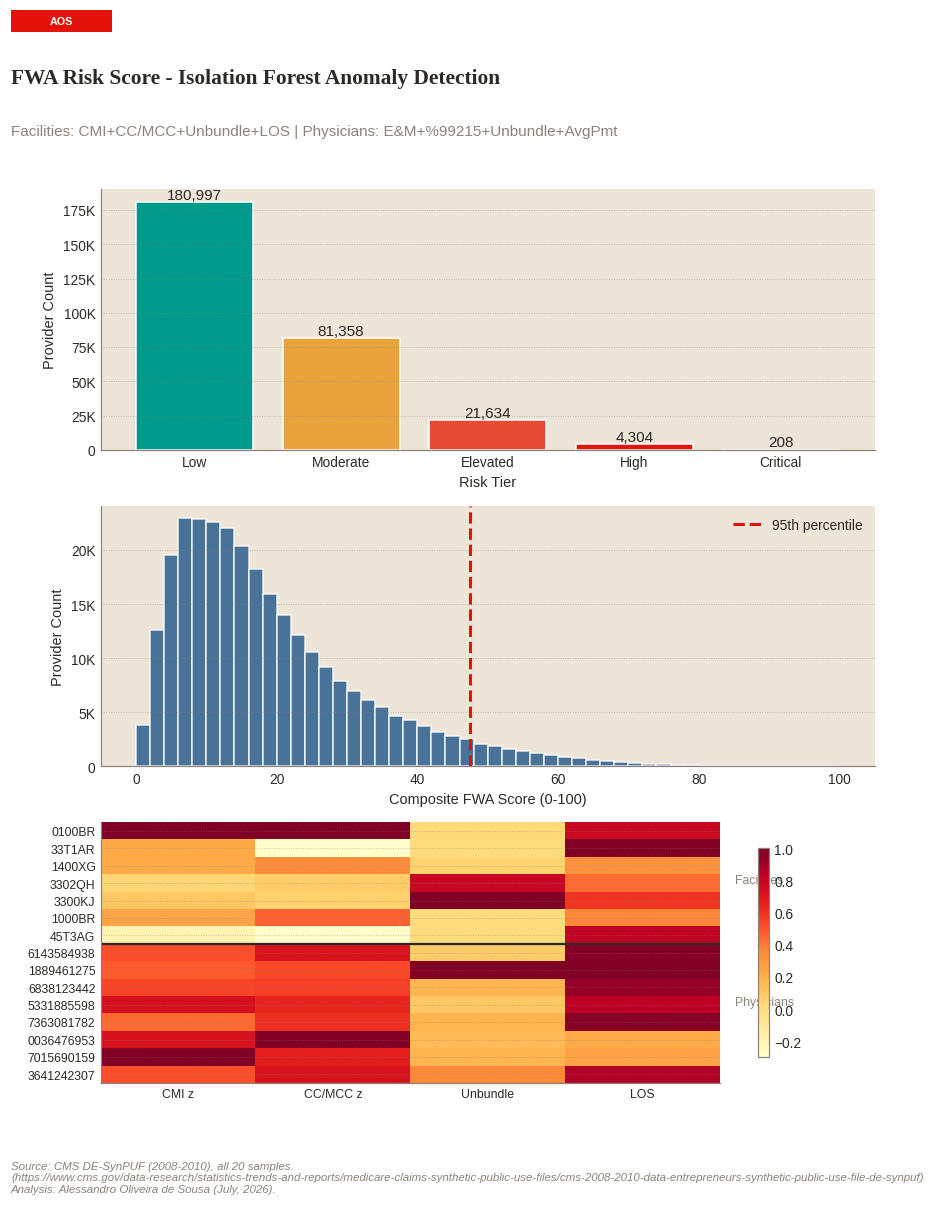

In [139]:
# ============================================================
# 10.2 - Risk score visualization
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(8, 10))

# Risk tier bar chart
ax = axes[0]
tiers = combined['risk_tier'].value_counts().sort_index()
tier_colors = [NATURE_TEAL, AMBER, NATURE_CORAL, ECON_RED, PLUM]
bars = ax.bar(tiers.index.astype(str), tiers.values,
              color=tier_colors[:len(tiers)], edgecolor='white')
for bar, val in zip(bars, tiers.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,}', ha='center', va='bottom', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
    #ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
finalizar_eixo(ax, xlabel='Risk Tier', ylabel='Provider Count')

# Score distribution
ax = axes[1]
ax.hist(combined['composite_risk'], bins=50, color=DEEP_BLUE, edgecolor='white', alpha=0.85)
ax.axvline(combined['composite_risk'].quantile(0.95), color=ECON_RED,
           linestyle='--', linewidth=2, label='95th percentile')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
#ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
finalizar_eixo(ax, xlabel='Composite FWA Score (0-100)', ylabel='Provider Count')
ax.legend()

# Heatmap top 15 - using Isolation Forest feature vectors
print(f'facility_risk columns: {list(facility_risk.columns)}')
print(f'physician_risk columns: {list(physician_risk.columns)}')
ax = axes[2]
fac_cols = ['cmi_zscore','cc_zscore','unbundle_count','mean_los']
phy_cols = ['hl_zscore','ratio_99215','unbundle_count','mean_em_pmt']

top_fac = facility_risk.nlargest(7, 'composite_risk')[['provider_id'] + fac_cols].copy()
top_phy = physician_risk.nlargest(8, 'composite_risk')[['provider_id'] + phy_cols].copy()

# Normalize each column 0-1 for comparable heatmap colors
for col in fac_cols:
    cmax = top_fac[col].abs().max()
    top_fac[col] = top_fac[col] / cmax if cmax > 0 else 0
for col in phy_cols:
    cmax = top_phy[col].abs().max()
    top_phy[col] = top_phy[col] / cmax if cmax > 0 else 0

top_fac.columns = ['provider_id','Sig1','Sig2','Sig3','Sig4']
top_phy.columns = ['provider_id','Sig1','Sig2','Sig3','Sig4']
hm_df = pd.concat([top_fac, top_phy], ignore_index=True)

im = ax.imshow(hm_df[['Sig1','Sig2','Sig3','Sig4']].values,
               cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(len(hm_df)))
ax.set_yticklabels([truncar(s, 12) for s in hm_df['provider_id']], fontsize=8)
ax.set_xticks(range(4))
ax.set_xticklabels(['CMI z','CC/MCC z','Unbundle','LOS'], fontsize=8)
ax.axhline(6.5, color=CHARCOAL, linewidth=1.5)
ax.text(3.6, 3, 'Facilities', fontsize=8, color=WARM_GREY, va='baseline')
ax.text(3.6, 10, 'Physicians', fontsize=8, color=WARM_GREY, va='baseline')
plt.colorbar(im, ax=ax, shrink=0.8)

titulo_fig(fig, 'FWA Risk Score - Isolation Forest Anomaly Detection',
           subtitulo='Facilities: CMI+CC/MCC+Unbundle+LOS | Physicians: E&M+%99215+Unbundle+AvgPmt')
assinatura_cmcia(fig)
plt.tight_layout(rect=[0, 0.02, 1, 0.88])
plt.show()

---
## Section 10b - Financial Impact Estimation

Detection without financial quantification is incomplete. For each flagged provider, we estimate the excess payment.

In [130]:
# ============================================================
# 10b.1 - Financial impact estimation
# ============================================================
# For each flagged provider, estimate excess payment as the difference between actual billing and population mean,
# scaled by volume.
# ============================================================

# DRG upcoding financial impact
flagged_ip = provider_cmi[provider_cmi['cmi_flag']].copy()
total_exposure = 0

if len(flagged_ip) > 0:
    flagged_ip['cmi_excess'] = flagged_ip['cmi'] - cmi_mean
    flagged_ip['est_overpayment'] = (
        flagged_ip['cmi_excess'] / cmi_mean *
        flagged_ip['mean_pmt'] *
        flagged_ip['claim_count'] * 0.15
    )
    drg_excess = flagged_ip['est_overpayment'].sum()
    total_exposure += drg_excess
    print('FINANCIAL IMPACT - DRG Upcoding')
    print('=' * 60)
    print(f'Flagged providers:           {len(flagged_ip):,}')
    print(f'Total estimated overpayment: ${drg_excess:,.0f}')
    print(f'Average per provider:        ${drg_excess / len(flagged_ip):,.0f}')

# E&M upcoding financial impact
flagged_em = provider_em[provider_em['em_upcoding_flag']].copy()

if len(flagged_em) > 0:
    EM_LEVEL_DIFFERENTIAL = 35.0
    flagged_em['excess_visits'] = (flagged_em['high_level_ratio'] - hl_mean) * flagged_em['total_em_visits']
    flagged_em['est_overpayment'] = flagged_em['excess_visits'] * EM_LEVEL_DIFFERENTIAL
    em_excess = flagged_em['est_overpayment'].sum()
    total_exposure += em_excess
    print(f'\nFINANCIAL IMPACT - E&M Upcoding')
    print('=' * 60)
    print(f'Flagged providers:           {len(flagged_em):,}')
    print(f'Total excess visits:         {flagged_em["excess_visits"].sum():,.0f}')
    print(f'Total estimated overpayment: ${em_excess:,.0f}')

print(f'\nCOMBINED FINANCIAL EXPOSURE: ${total_exposure:,.0f}')


FINANCIAL IMPACT - DRG Upcoding
Flagged providers:           87
Total estimated overpayment: $1,695,143
Average per provider:        $19,484

FINANCIAL IMPACT - E&M Upcoding
Flagged providers:           8,495
Total excess visits:         47,878
Total estimated overpayment: $1,675,718

COMBINED FINANCIAL EXPOSURE: $3,370,861


---
## Section 10c - Provider Case Study: Deep Dive

A detection flag is the beginning of an investigation. This section examines the specific claims, codes, and patterns driving the highest-risk flags.

In [ ]:
# ============================================================
# 10c.1 - Case study: highest-risk facility + physician
# ============================================================
# A detection flag is the beginning of an investigation. This section takes the top provider from each type and
# examines the specific claims and codes driving the flag.
# ============================================================

# Facility case study
if len(flagged_ip) > 0:
    top_fac = flagged_ip.nlargest(1, 'cmi_zscore').iloc[0]
    fid = top_fac['PRVDR_NUM']
    print(f'CASE STUDY - Facility: {fid}')
    print('=' * 60)
    print(f'CMI:            {top_fac["cmi"]:.4f} (population: {cmi_mean:.4f})')
    print(f'CMI z-score:    {top_fac["cmi_zscore"]:.2f}')
    print(f'Claim count:    {top_fac["claim_count"]:,.0f}')
    print(f'Mean payment:   ${top_fac["mean_pmt"]:,.2f}')
    print(f'Mean LOS:       {top_fac["mean_los"]:.1f} days')

    fac_drgs = con.execute(f"""
        SELECT ic.CLM_DRG_CD, COUNT(*) AS n, AVG(TRY_CAST(ic.CLM_PMT_AMT AS DOUBLE)) AS avg_pmt,
               dw.drg_weight
        FROM inpatient_claims ic
        JOIN t_drg_weights dw ON ic.CLM_DRG_CD = dw.CLM_DRG_CD
        WHERE ic.PRVDR_NUM = '{fid}'
        GROUP BY ic.CLM_DRG_CD, dw.drg_weight ORDER BY n DESC LIMIT 15
    """).fetchdf()
    print(f'\nTop DRGs billed:')
    print(fac_drgs.to_string(index=False))

# Physician case study
if len(flagged_em) > 0:
    top_doc = flagged_em.nlargest(1, 'hl_zscore').iloc[0]
    did = top_doc['PRF_NPI']
    print(f'\n\nCASE STUDY - Physician NPI: {did}')
    print('=' * 60)
    print(f'High-level ratio:  {top_doc["high_level_ratio"]:.2%} (pop: {hl_mean:.2%})')
    print(f'Z-score:           {top_doc["hl_zscore"]:.2f}')
    print(f'Total visits:      {top_doc["total_em_visits"]:,.0f}')

    print(f'\nE&M breakdown (provider vs. population):')
    for code in ['99211','99212','99213','99214','99215']:
        pn = top_doc[f'n_{code}']
        pp = pn / top_doc['total_em_visits'] * 100
        pop = provider_em[f'n_{code}'].sum() / provider_em['total_em_visits'].sum() * 100
        flag = ' <<<' if code in ('99214','99215') and pp > pop * 1.5 else ''
        print(f'  {code}: {pp:6.1f}% (pop: {pop:5.1f}%){flag}')

    if len(df_viol_by_provider) > 0:
        dv = df_viol_by_provider[df_viol_by_provider['PRF_NPI'] == did]
        if len(dv) > 0:
            n_viol = dv['n_violations'].iloc[0]
            print(f'\nAlso has {n_viol:,} NCCI unbundling violations.')
        else:
            print(f'\nNo NCCI unbundling violations for this provider.')


CASE STUDY - Facility: 0100BR
CMI:            4.8481 (population: 2.0077)
CMI z-score:    13.80
Claim count:    14
Mean payment:   $15,285.71
Mean LOS:       7.9 days

Top DRGs billed:
CLM_DRG_CD  n   avg_pmt  drg_weight
       129  1  3,000.00        2.07
       064  1 10,000.00        1.83
       185  1  5,000.00        0.67
       222  1  2,000.00        8.48
       485  1 10,000.00        3.09
       204  1  7,000.00        0.65
       221  1  5,000.00        4.39
       236  1 12,000.00        3.61
       291  1  4,000.00        1.46
       OTH  1      0.00        3.91
       220  1  5,000.00        5.18
       011  1 57,000.00        4.73
       001  1 57,000.00       24.85
       199  1  7,000.00        1.83
       981  1 30,000.00        5.04


CASE STUDY - Physician NPI: 5760905563
High-level ratio:  80.00% (pop: 38.51%)
Z-score:           5.36
Total visits:      20

E&M breakdown (provider vs. population):
  99211:   10.0% (pop:   4.3%)
  99212:    0.0% (pop:   9.4%)
  99213:

---
## Section 10d - Geographic Distribution

Geographic clustering of FWA is well-documented (OIG Report OEI-03-11-00210). Uses beneficiary state codes as proxy.

Geographic Distribution - E&M Flagged Providers (top 20 states)
state  n_providers
   10           84
   54           74
   33           66
   05           54
   39           49
   14           46
   31           44
   34           33
   45           33
   22           32
   36           31
   23           31
   15           30
   11           29
   42           29
   49           25
   03           24
   50           22
   52           21
   21           20


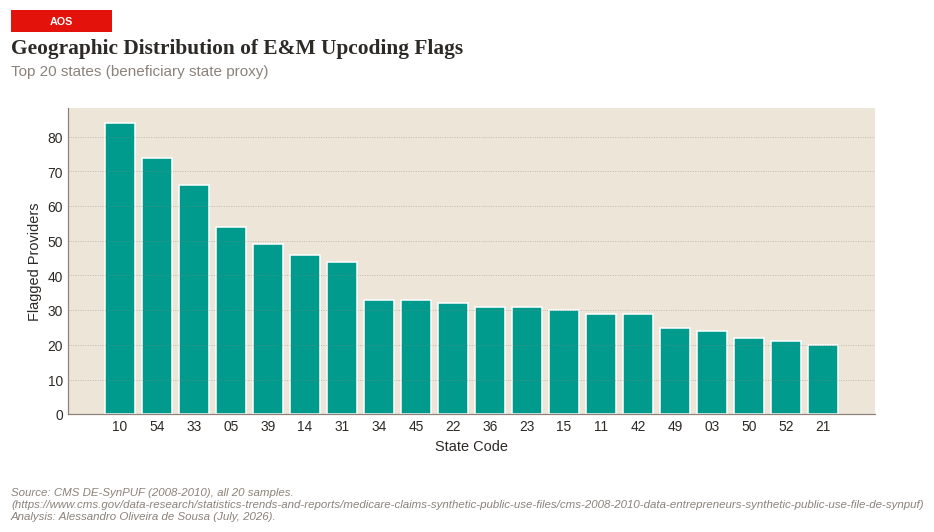

In [ ]:
# ============================================================
# 10d.1 - Geographic distribution of flagged providers
# ============================================================
# Use beneficiary SP_STATE_CODE as proxy for provider location. Geographic clustering of FWA is well-documented (OIG).
# ============================================================

if len(flagged_em) > 0:
    top_npis = flagged_em.nlargest(500, 'hl_zscore')['PRF_NPI'].tolist()
    npi_values = ",".join(f"\'{n}\'" for n in top_npis)

    geo = con.execute(f"""
        SELECT b.SP_STATE_CODE AS state,
               COUNT(DISTINCT cl.PRF_NPI) AS n_providers
        FROM (
            SELECT DISTINCT DESYNPUF_ID, PRF_NPI
            FROM v_carrier_lines WHERE PRF_NPI IN ({npi_values})
        ) cl
        JOIN beneficiary b ON cl.DESYNPUF_ID = b.DESYNPUF_ID
        WHERE b.SP_STATE_CODE IS NOT NULL AND b.SP_STATE_CODE != ''
        GROUP BY state ORDER BY n_providers DESC LIMIT 20
    """).fetchdf()

    if len(geo) > 0:
        print('Geographic Distribution - E&M Flagged Providers (top 20 states)')
        print('=' * 60)
        print(geo.to_string(index=False))

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(geo['state'].astype(str), geo['n_providers'], color=NATURE_TEAL, edgecolor='white')
        finalizar_eixo(ax, xlabel='State Code', ylabel='Flagged Providers')
        titulo_fig(fig, 'Geographic Distribution of E&M Upcoding Flags',
                   subtitulo='Top 20 states (beneficiary state proxy)')
        assinatura_cmcia(fig)
        plt.tight_layout(rect=[0, 0.02, 1, 0.88])
        plt.show()
    else:
        print('No geographic data available.')
else:
    print('No flagged providers for geographic analysis.')


---
## Section 10e - Provider Network Analysis (Beneficiary Sharing)

Fraud rings involve multiple providers sharing the same pool of beneficiaries. High Jaccard similarity of beneficiary panels between unrelated providers warrants investigation.

In [133]:
# ============================================================
# 10e.1 - Beneficiary sharing among flagged providers
# ============================================================
# Fraud rings involve multiple providers sharing beneficiaries. Compute Jaccard similarity of beneficiary panels for
# top flagged physicians. High overlap = fraud ring signal.
# ============================================================

if len(flagged_em) > 0:
    top_fl = flagged_em.nlargest(50, 'hl_zscore')['PRF_NPI'].tolist()
    if len(top_fl) >= 2:
        npi_clause = ",".join(f"\'{n}\'" for n in top_fl)
        bsets = con.execute(f"""
            SELECT PRF_NPI, LIST(DISTINCT DESYNPUF_ID) AS benes
            FROM v_carrier_lines WHERE PRF_NPI IN ({npi_clause})
            GROUP BY PRF_NPI
        """).fetchdf()
        bs = {r['PRF_NPI']: set(r['benes']) for _, r in bsets.iterrows()}

        pairs = []
        plist = list(bs.keys())
        for i in range(len(plist)):
            for j in range(i+1, len(plist)):
                s1, s2 = bs[plist[i]], bs[plist[j]]
                shared = len(s1 & s2)
                if shared >= 3:
                    pairs.append({'prov_1': plist[i], 'prov_2': plist[j],
                                  'shared': shared, 'jaccard': shared / len(s1 | s2),
                                  'panel_1': len(s1), 'panel_2': len(s2)})

        df_ov = pd.DataFrame(pairs)
        if len(df_ov) > 0:
            df_ov = df_ov.sort_values('shared', ascending=False)
            print('BENEFICIARY SHARING - Top 50 Flagged Providers')
            print('=' * 60)
            print(f'Pairs with >= 3 shared beneficiaries: {len(df_ov):,}')
            print(f'Max Jaccard similarity: {df_ov["jaccard"].max():.3f}')
            print(f'\nTop 15 pairs:')
            print(df_ov.head(15).to_string(index=False))
        else:
            print('No significant beneficiary overlap among flagged providers.')


No significant beneficiary overlap among flagged providers.


---
## Section 11 - Executive Summary & Export

In [134]:
# ============================================================
# 11.1 — Executive summary
# ============================================================

print('\n' + '=' * 70)
print('        FWA DETECTION ENGINE — EXECUTIVE SUMMARY')
print('=' * 70)

print(f'\n  DATASET')
print(f'  {"─"*50}')
print(f'  Source:              CMS DE-SynPUF (all 20 samples)')
print(f'  Platform:            DuckDB analytical datalake')
for tbl, stats in table_stats.items():
    if not tbl.startswith('v_'):
        print(f'  {tbl:25s}: {stats["count"]:>12,} records')

print(f'\n  M1 — DRG UPCODING')
print(f'  {"─"*50}')
print(f'  CMI analysis:           {len(provider_cmi):>8,} providers, '
      f'{provider_cmi["cmi_flag"].sum()} flagged')
print(f'  CC/MCC analysis:        {len(provider_cc):>8,} providers, '
      f'{provider_cc["cc_flag"].sum()} flagged')

print(f'\n  M2 — E&M UPCODING')
print(f'  {"─"*50}')
print(f'  Providers analyzed:     {len(provider_em):>8,}')
print(f'  Flagged:                {provider_em["em_upcoding_flag"].sum():>8,}')

print(f'\n  M3 — NCCI UNBUNDLING (Full PTP File, 2008-2010)')
print(f'  {"─"*50}')
print(f'  Carrier within-claim:   {n_total_violations:>12,} violations')
print(f'  Carrier cross-claim:    {total_cross_violations:>12,} violations')
print(f'  Outpatient:             {total_op_violations:>12,} violations')
total_all_viol = n_total_violations + total_cross_violations + total_op_violations
print(f'  Total:                  {total_all_viol:>12,} violations')
print(f'  Unique providers (carrier): {n_unique_providers:>8,}')

print(f'\n  M4 — COMPOSITE RISK (Isolation Forest)')
print(f'  {"─"*50}')
for lbl, df in [('Facilities', facility_risk), ('Physicians', physician_risk)]:
    n_anom = df['is_anomaly'].sum()
    elevated = (df['risk_tier'].isin(['Elevated','High','Critical'])).sum()
    print(f'  {lbl}: {len(df):,} scored, {n_anom:,} anomalies, '
          f'{elevated} elevated+')

if total_exposure > 0:
    print(f'\n  FINANCIAL EXPOSURE')
    print(f'  {"─"*50}')
    print(f'  Combined estimated overpayment: ${total_exposure:,.0f}')

print(f'\n' + '=' * 70)


        FWA DETECTION ENGINE — EXECUTIVE SUMMARY

  DATASET
  ──────────────────────────────────────────────────
  Source:              CMS DE-SynPUF (all 20 samples)
  Platform:            DuckDB analytical datalake
  beneficiary              :    6,873,274 records
  carrier_claims           :   94,863,452 records
  inpatient_claims         :    1,332,822 records
  outpatient_claims        :   15,826,987 records
  prescription_drug_events :  111,085,969 records

  M1 — DRG UPCODING
  ──────────────────────────────────────────────────
  CMI analysis:              2,802 providers, 87 flagged
  CC/MCC analysis:           2,802 providers, 86 flagged

  M2 — E&M UPCODING
  ──────────────────────────────────────────────────
  Providers analyzed:      285,699
  Flagged:                   8,495

  M3 — NCCI UNBUNDLING (Full PTP File, 2008-2010)
  ──────────────────────────────────────────────────
  Carrier within-claim:     12,733,318 violations
  Carrier cross-claim:           7,406 violati

In [ ]:
# ============================================================
# 11.2 — Export results
# ============================================================

CSV_PARAMS = {'index': False, 'sep': ';', 'encoding': 'utf-8-sig'}

# Combined provider risk scores (facility + physician)
combined.to_csv(OUTPUT_DIR / 'provider_risk_scores.csv', **CSV_PARAMS)
print(f'Exported: provider_risk_scores.csv ({len(combined):,})')

# Facility risk detail
facility_risk.to_csv(OUTPUT_DIR / 'facility_risk_detail.csv', **CSV_PARAMS)
print(f'Exported: facility_risk_detail.csv ({len(facility_risk):,})')

# Physician risk detail
physician_risk.to_csv(OUTPUT_DIR / 'physician_risk_detail.csv', **CSV_PARAMS)
print(f'Exported: physician_risk_detail.csv ({len(physician_risk):,})')

# NCCI violations — aggregated by provider (carrier within-claim)
if len(df_viol_by_provider) > 0:
    df_viol_by_provider.to_csv(OUTPUT_DIR / 'ncci_violations_by_provider_carrier.csv', **CSV_PARAMS)
    print(f'Exported: ncci_violations_by_provider_carrier.csv ({len(df_viol_by_provider):,})')

# NCCI violations — aggregated by provider (cross-claim)
if len(df_cross_by_provider) > 0:
    df_cross_by_provider.to_csv(OUTPUT_DIR / 'ncci_violations_by_provider_cross.csv', **CSV_PARAMS)
    print(f'Exported: ncci_violations_by_provider_cross.csv ({len(df_cross_by_provider):,})')

# NCCI violations — aggregated by provider (outpatient)
if len(df_op_by_provider) > 0:
    df_op_by_provider.to_csv(OUTPUT_DIR / 'ncci_violations_by_provider_outpatient.csv', **CSV_PARAMS)
    print(f'Exported: ncci_violations_by_provider_outpatient.csv ({len(df_op_by_provider):,})')

# NCCI violations — by type (all sources combined, for Pareto reference)
if 'pareto' in dir() and len(pareto) > 0:
    pareto.to_csv(OUTPUT_DIR / 'ncci_violations_pareto.csv', **CSV_PARAMS)
    print(f'Exported: ncci_violations_pareto.csv ({len(pareto):,})')

# DRG upcoding flagged (with financial impact)
if len(flagged_ip) > 0:
    flagged_ip.to_csv(OUTPUT_DIR / 'drg_upcoding_flagged.csv', **CSV_PARAMS)
    print(f'Exported: drg_upcoding_flagged.csv ({len(flagged_ip):,})')

# E&M upcoding flagged (with financial impact)
if len(flagged_em) > 0:
    flagged_em.to_csv(OUTPUT_DIR / 'em_upcoding_flagged.csv', **CSV_PARAMS)
    print(f'Exported: em_upcoding_flagged.csv ({len(flagged_em):,})')

# CC/MCC flagged
cc_f = provider_cc[provider_cc['cc_flag']]
if len(cc_f) > 0:
    cc_f.to_csv(OUTPUT_DIR / 'cc_mcc_flagged.csv', **CSV_PARAMS)
    print(f'Exported: cc_mcc_flagged.csv ({len(cc_f):,})')

print(f'\nAll results exported to: {OUTPUT_DIR.resolve()}')

Exported: provider_risk_scores.csv (288,501)
Exported: facility_risk_detail.csv (2,802)
Exported: physician_risk_detail.csv (285,699)
Exported: ncci_violations_by_provider_carrier.csv (642,505)
Exported: ncci_violations_by_provider_cross.csv (2,040)
Exported: ncci_violations_by_provider_outpatient.csv (6,476)
Exported: ncci_violations_pareto.csv (12)
Exported: drg_upcoding_flagged.csv (87)
Exported: em_upcoding_flagged.csv (8,495)
Exported: cc_mcc_flagged.csv (86)

All results exported to: /home/aosousa/Documents/PORTFOLIO/Fraud-Waste-Abuse-FWA/CMS DE-SynPUF MEDICARE/output/fwa_desynpuf


In [ ]:
# ============================================================
# 11.3 - Close database connection
# ============================================================
con.close()
print('DuckDB connection closed.')

---
## Section 12 - Production Readiness Notes

### Adapting This Engine to Real Medicare Claims Data

This pipeline is designed for direct transfer to production environments. Key adaptations:

1. **DRG Weights:** Replace proxy weights with official CMS MS-DRG Relative Weights from the IPPS Final Rule.

2. **NCCI PTP Edits:** Load the complete quarterly NCCI PTP edit file (~1.9M pairs) from CMS. Include modifier indicator logic: pairs with indicator=1 should only be flagged when no appropriate modifier (-59, -XE, -XS, -XP, -XU) is present.

3. **Provider Enrichment:** Use real NPI numbers to join with the NPPES registry for specialty, taxonomy, and geographic peer grouping.

4. **Temporal Analysis:** Track risk scores over time. Sudden changes in billing patterns are strong FWA signals.

5. **ML Extensions:** Isolation Forest for unsupervised anomaly detection; supervised classification using OIG audit outcomes; graph-based network analysis for fraud ring detection.

6. **Regulatory Alignment:**
   - CMS Program Integrity Manual (Chapter 3)
      - [https://www.cms.gov/regulations-and-guidance/guidance/manuals/downloads/pim83c03.pdf](URL)
   - OIG Work Plan priorities
      - [https://oig.hhs.gov/reports/work-plan/](URL)
      - [https://oig.hhs.gov/documents/evaluation/2687/OEI-02-18-00380-Complete%20Report.pdf](URL)
   - False Claims Act (31 U.S.C. 3729-3733)
      - [https://uscode.house.gov/view.xhtml?req=granuleid:USC-prelim-title31-section3729&num=0&edition=prelim](URL)
      - [https://www.law.cornell.edu/uscode/text/31/subtitle-III/chapter-37/subchapter-III](URL)

### DuckDB in Production

The same DuckDB architecture demonstrated here scales to production CMS datasets (100M+ claims). For larger volumes or team collaboration, the DuckDB file can be replaced with DuckDB reading from partitioned Parquet files on S3/GCS, maintaining the same SQL interface.

---

*This FWA detection engine was developed as a portfolio demonstration of healthcare claims auditing capabilities. The methodology draws from established CMS Program Integrity practices, OIG audit methodologies, and peer-reviewed literature on DRG upcoding detection (Rosenberg et al., 2000; Bauder et al., 2017).*

---
## Section 12 — From Unsupervised to Supervised: The Feedback Loop

### The Concept Drift Problem

The Isolation Forest deployed in Module M4 is a point-in-time anomaly detector. It identifies providers whose current billing patterns deviate from the population norm. However, billing norms shift over time: new CPT codes are introduced, reimbursement rates change, and — critically — fraudulent providers adapt their strategies to evade detection.

This is **concept drift**: the statistical properties of the target variable change over time, degrading model accuracy. An Isolation Forest trained on 2008-2010 data will become progressively less effective as billing patterns evolve.

### The Supervised Feedback Architecture

The transition from unsupervised to supervised learning requires a **labeled feedback loop** from the clinical auditing team:

``` 
┌─────────────────────────────────────────────────────────┐
│ DETECTION (Current Pipeline)                            │
│ Isolation Forest → Anomaly Scores → Ranked Provider List│
│ ↓                                                       │
│ INVESTIGATION (Human Auditors)                          │
│ Top-N providers reviewed → Clinical documentation audit │
│ ↓                                                       │
│ LABELING                                                │
│ Confirmed Fraud | False Positive | Insufficient Evidence│
│ ↓                                                       │
│ RETRAINING                                              │
│ Labeled outcomes → Supervised model (XGBoost/LightGBM)  │
│ Features: same as IF + temporal deltas + peer ratios    │
│ ↓                                                       │
│ DEPLOYMENT                                              │
│ Supervised model replaces/augments IF for scoring       │
│ IF retained as "novelty detector" for unseen patterns   │
│ ↓                                                       │
│ MONITORING                                              │
│ Track precision/recall quarterly                        │
│ Retrain when precision drops below threshold            │
└─────────────────────────────────────────────────────────┘
```

### Implementation Details

1. **Label collection**: After each audit cycle, the investigating team records the outcome (confirmed fraud, false positive, or inconclusive) in a structured table keyed by `provider_id` and `audit_date`. Minimum viable dataset: ~500 labeled outcomes (50+ confirmed positives).

2. **Feature augmentation for supervised model**: The same features used by the Isolation Forest, plus temporal features (billing pattern slope over trailing 12 months, month-over-month CMI delta), peer-relative features (provider CMI / specialty mean CMI), and the IF anomaly score itself as a meta-feature.

3. **Model selection**: Gradient-boosted trees (XGBoost or LightGBM) are the standard choice for tabular fraud detection — they handle mixed feature types, provide feature importance, and train in seconds on provider-level data.

4. **Dual-model deployment**: The supervised model handles known fraud patterns (high precision). The Isolation Forest is retained as a "novelty detector" — it catches emerging fraud schemes that the supervised model hasn't been trained on. Alerts from either model trigger investigation.

5. **Retraining cadence**: Quarterly, aligned with NCCI PTP edit releases and CMS fee schedule updates. The pipeline ingests new labels, retrains both models, and generates a model performance report (precision, recall, F1, AUC-ROC) compared to the previous quarter.